# Hand Gesture Recognition

In [95]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from scipy.fft import fft, fftfreq
from scipy import signal
from scipy.signal import butter
from numpy import mean, std

from enum import IntEnum

import neurokit2 as nk
from sklearn.preprocessing import RobustScaler

from pickle import dump

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import libemg

import gc

In [96]:
# global variables
test_subject = 'nad'
# base_dir = '/home/madnad/practice/Pervasive_Computing_Lab/git/recordings/19_12_24'
base_dir = '/home/madnad/practice/Pervasive_Computing_Lab/git/recordings'
num_classes = 6
lf = 20
hf = 500
fs = 1150
trim = 4*8*5
bandpass_order = 4
outlier_rejection_stds = 6

plot_all_timeline = False
num_sensors = 4

In [108]:
class Classes(IntEnum):
    # NEUTRAL = 0,
    FIST = 0,
    INDEX = 1,
    MIDDLE = 2,
    OK = 3,
    PEACE = 4,
    THUMB = 5
    
# structure: recordings/date/data/*.csv
files = [[] for _ in range(num_classes)]
baseline_file = None

for date_dir, _, filenames in os.walk(base_dir):
    if date_dir.endswith('data'):
        for filename in filenames:
            if not filename.startswith(test_subject):
                continue
            if filename.find('baseline') != -1:
                baseline_file = os.path.join(date_dir, filename)
            elif filename.find('fist') != -1:
                files[Classes.FIST].append(os.path.join(date_dir, filename))
            elif filename.find('index') != -1:
                files[Classes.INDEX].append(os.path.join(date_dir, filename))
            elif filename.find('middle') != -1:
                files[Classes.MIDDLE].append(os.path.join(date_dir, filename))
            elif filename.find('ok') != -1:
                files[Classes.OK].append(os.path.join(date_dir, filename))
            elif filename.find('peace') != -1:
                files[Classes.PEACE].append(os.path.join(date_dir, filename))
            elif filename.find('thumb') != -1:
                files[Classes.THUMB].append(os.path.join(date_dir, filename))

files = [file for file in files if len(file) > 0]
print(files)      

[['/home/madnad/practice/Pervasive_Computing_Lab/git/recordings/19_12_24/data/nad_fist_0.csv', '/home/madnad/practice/Pervasive_Computing_Lab/git/recordings/01_12_24_initial_placement_test/data/nad_fist_0.csv'], ['/home/madnad/practice/Pervasive_Computing_Lab/git/recordings/19_12_24/data/nad_index_0.csv', '/home/madnad/practice/Pervasive_Computing_Lab/git/recordings/01_12_24_initial_placement_test/data/nad_index_0.csv'], ['/home/madnad/practice/Pervasive_Computing_Lab/git/recordings/19_12_24/data/nad_middle_0.csv', '/home/madnad/practice/Pervasive_Computing_Lab/git/recordings/01_12_24_initial_placement_test/data/nad_middle_0.csv'], ['/home/madnad/practice/Pervasive_Computing_Lab/git/recordings/19_12_24/data/nad_ok_0.csv', '/home/madnad/practice/Pervasive_Computing_Lab/git/recordings/01_12_24_initial_placement_test/data/nad_ok_0.csv'], ['/home/madnad/practice/Pervasive_Computing_Lab/git/recordings/19_12_24/data/nad_peace_0.csv', '/home/madnad/practice/Pervasive_Computing_Lab/git/recordi

Our initial static gesture recording includes 7 classes: neutral, fist, index finger, middle finger, ok, peace, thumb.

In [119]:
# neutral_df = [pd.read_csv(file, header=None) for file in files[Classes.NEUTRAL]]
fist_df = [pd.read_csv(file, header=None) for file in files[Classes.FIST]]
index_df = [pd.read_csv(file, header=None) for file in files[Classes.INDEX]]
middle_df = [pd.read_csv(file, header=None) for file in files[Classes.MIDDLE]]
ok_df = [pd.read_csv(file, header=None) for file in files[Classes.OK]]
peace_df = [pd.read_csv(file, header=None) for file in files[Classes.PEACE]]
thumb_df = [pd.read_csv(file, header=None) for file in files[Classes.THUMB]]
baseline_df = pd.read_csv(baseline_file, header=None)

Optional subsampling:

In [120]:
def get_min_df_array_len(dfs):
    min_len = min([len(df_) for df in dfs for df_ in df])
    return min_len

def get_min_df_len(dfs):
    min_len = min([len(df) for df in dfs])
    return min_len
# min_len = get_min_df_len([fist_df, index_df, middle_df, ok_df, peace_df, thumb_df])
# print('Min length:', min_len)
# # min_len = get_min_df_len([fist_df, index_df, middle_df, ok_df, peace_df, thumb_df, [baseline_df]])
# baseline_array = baseline_df.values
# if min_len > len(baseline_array):
#     baseline_array = np.concatenate([baseline_array for _ in range(min_len // len(baseline_array))])
#     baseline_array = np.concatenate([baseline_array, baseline_array[:min_len % len(baseline_array)]])
# else:
#     baseline_array = baseline_array[:min_len]

In [121]:
num_samples = get_min_df_array_len([fist_df, index_df, middle_df, ok_df, peace_df, thumb_df])

# neutral_df = pd.concat([df.sample(num_samples) for df in neutral_df])
fist_df = pd.concat([df.sample(num_samples) for df in fist_df])
index_df = pd.concat([df.sample(num_samples) for df in index_df])
middle_df = pd.concat([df.sample(num_samples) for df in middle_df])
ok_df = pd.concat([df.sample(num_samples) for df in ok_df])
peace_df = pd.concat([df.sample(num_samples) for df in peace_df])
thumb_df = pd.concat([df.sample(num_samples) for df in thumb_df])

min_len = get_min_df_len([fist_df, index_df, middle_df, ok_df, peace_df, thumb_df])
print('Min length of combined dataframes:', min_len)
# min_len = get_min_df_len([fist_df, index_df, middle_df, ok_df, peace_df, thumb_df, [baseline_df]])
baseline_array = baseline_df.values
if min_len > len(baseline_array):
    baseline_array = np.concatenate([baseline_array for _ in range(min_len // len(baseline_array))])
    baseline_array = np.concatenate([baseline_array, baseline_array[:min_len % len(baseline_array)]])
else:
    baseline_array = baseline_array[:min_len]

Min length of combined dataframes: 9108


In [130]:
len(fist_df), len(index_df), len(middle_df), len(ok_df), len(peace_df), len(thumb_df), len(baseline_array)

(9108, 9108, 9108, 9108, 9108, 9108, 9108)

In [133]:
ok_df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
3210,17726,17728,17691,17676,17742,17735,17747,17783,17546,17527,...,17016,17174,17533,17528,17518,17503,17550,17563,17624,17693
283,18090,18035,18090,18136,18152,18215,18230,18247,18579,18612,...,16733,16980,18066,18108,18170,18227,18282,18304,18316,18240
4751,17699,17711,17712,17692,17648,17633,17655,17672,17984,17989,...,17679,17558,17627,17711,17758,17774,17768,17784,17754,17788
1399,17863,17804,17681,17666,17749,17780,17770,17823,18476,18544,...,17433,17436,18008,17917,17871,17891,17955,17995,17973,17950
2581,17903,17922,17907,17888,17866,17856,17844,17867,17965,17994,...,18055,18020,18116,18102,18061,18041,18040,18036,17982,17972


Combine dataframes

In [131]:
df = pd.concat([fist_df, index_df, middle_df, ok_df, peace_df, thumb_df], ignore_index=True)

print(df.head())

      0      1      2      3      4      5      6      7      8      9   ...  \
0  18443  18418  18425  18419  18404  18376  18351  18355  17270  17291  ...   
1  17452  17503  17508  17485  17464  17456  17364  17373  17348  17310  ...   
2  17641  17504  17438  17239  17165  17582  17919  18001  17286  17353  ...   
3  19085  18888  18764  18659  18623  18513  18269  18360  19433  19409  ...   
4  18890  18871  18835  18811  18787  18773  18753  18761  18095  18099  ...   

      22     23     24     25     26     27     28     29     30     31  
0  17039  17055  19109  19137  19153  19147  19079  19117  19137  19187  
1  16731  16820  18189  18203  18200  18193  18218  18241  18268  18279  
2  16811  16681  18614  18149  17973  18127  17990  17610  17423  16952  
3  17234  17309  18507  18387  17959  17566  18592  19431  19035  18534  
4  18610  18579  19739  19719  19670  19669  19661  19675  19618  19580  

[5 rows x 32 columns]


In [132]:
sensor_data = df.iloc[:, :]
labels = [Classes.FIST]*len(fist_df) + [Classes.INDEX]*len(index_df) + [Classes.MIDDLE]*len(middle_df) + [Classes.OK]*len(ok_df) + [Classes.PEACE]*len(peace_df) + [Classes.THUMB]*len(thumb_df)

## Preprocessing

In [180]:
class EMG_preprocessor():
    def __init__(self, lf, hf, fs, trim, filter_order, outlier_rejection_stds, baseline_signal=None, filter_type='band', library='scipy'):
        self.lf = lf
        self.hf = hf
        self.fs = fs
        self.trim = trim
        self.filter_order = filter_order
        self.outlier_rejection_stds = outlier_rejection_stds
        self.filter_type = filter_type
        self.library = library
        self.baseline_mean = [[0.0] for _ in range(num_sensors)]
        self.baseline_noise = [[0.0] for _ in range(num_sensors)]
        if baseline_signal is not None:
            self.baseline_signal = [[] for _ in range(num_sensors)]
            baseline_signal = np.array_split(baseline_signal, num_sensors)
            for i in range(num_sensors):
                self.baseline_signal[i] = np.asarray(baseline_signal[i]).flatten()
                
            print('Baseline signal provided')
            self._calculate_baseline_noise(filter=True) # calculates baseline noise for each sensor
            self._calculate_baseline_mean() # calculates baseline mean for each sensor
            for i in range(num_sensors):
                self.baseline_signal[i] = self.baseline_signal[i] - self.baseline_mean[i]
        else:
            self.baseline_signal = None

    def calibrate(self, sensor_data):
        self.library = self._maximize_SNR(sensor_data)

    def preprocess(self, sensor_data, sensor_num):
        if self.library == 'scipy':
            return self._preprocess_data_scipy(sensor_data, sensor_num)
        elif self.library == 'nk2':
            return self._preprocess_data_nk2(sensor_data, sensor_num)
        elif self.library == 'libemg':
            return self._preprocess_data_libemg(sensor_data, sensor_num)
        else:
            return sensor_data
        
    def _preprocess_data_libemg(self, data, sensor_num):
        # instantiate the filter object with the sampling frequency
        fi = libemg.filtering.Filter(self.fs)
        # install filters to the filter object
        fi.install_common_filters()
        # run the entire first subject dataset through the common filters
        raw_data = fi.filter(data)
        return raw_data

    def _preprocess_data_nk2(self, data, sensor_num):
        # raw_data = self._apply_filter(data)
        # raw_data = self._remove_artefact(raw_data)
        raw_data = data
        # raw_data = self._subtract_baseline(raw_data, sensor_num)
        raw_data = self._calculate_linear_envelop(raw_data, sensor_num, plot=False)
        return raw_data

    def _calculate_linear_envelop(self, data, sensor_num, plot=False):
        feature='EMG_Amplitude'
        signals, info = nk.emg_process(data, sampling_rate=fs)
        if plot:
            nk.emg_plot(signals, info)
        return signals[feature].values
    
    # def _preprocess_data_emg_dsp_lib(self, data, sensor_num):
    #     ref_available = True if self.baseline_signal is not None else False
    #     self.emg_filter = EMG_filter(sample_frequency = self.fs, range_ = 0.5, min_EMG_frequency = self.lf, max_EMG_frequency = self.hf, reference_available = ref_available)
    #     sig = self.emg_filter.filter(data, self.baseline_signal[sensor_num].tolist())
    #     return sig

    def _remove_mean(self, data):
        return data - np.mean(data, axis=0)

    def _preprocess_data_scipy(self, data, sensor_num):
        data = self._apply_filter(data)
        data = self._remove_artefact(data)
        data = self._remove_outliers(data)
        data = self._remove_mean(data)
        data = self._subtract_baseline(data, sensor_num)
        return data
    
    def _preprocess_baseline_scipy(self, data):
        data = self._apply_filter(data)
        data = self._remove_artefact(data)
        data = self._remove_outliers(data)
        return data
    
    def _apply_filter(self, data):
        if self.filter_type == 'band':
            return self._apply_bandpass_filter(data)
        elif self.filter_type == 'highlow':
            return self._apply_highpasslowpass_filter(data)
        else:
            return data

    def _apply_bandpass_filter(self, data):
        sos = butter(self.filter_order, (self.lf, self.hf), btype="bandpass", fs=self.fs, output="sos")
        proc_data = signal.sosfilt(sos, data)
        return proc_data
    
    def _apply_highpasslowpass_filter(self, data):
        sos = butter(self.filter_order, self.lf, btype="highpass", fs=self.fs, output="sos")
        proc_data = signal.sosfilt(sos, data)
        sos = butter(self.filter_order, self.hf, btype="lowpass", fs=self.fs, output="sos")
        proc_data = signal.sosfilt(sos, proc_data)
        return proc_data

    def _remove_outliers(self, data):
        raw_data = data.flatten()
        data_mean, data_std = mean(raw_data), std(raw_data)
        cut_off = data_std * outlier_rejection_stds
        lower, upper = data_mean - cut_off, data_mean + cut_off

        outliers_removed = [x if x >= lower and x <= upper else 0.0 for x in raw_data]
        return outliers_removed

    def _remove_artefact(self, data):
        data[:trim] = 0
        return data
    
    def _calculate_baseline_mean(self):
        for i in range(num_sensors):
            self.baseline_mean[i] = np.mean(self.baseline_signal[i], axis=0)
    
    def _calculate_baseline_noise(self, filter=False):
        for i in range(num_sensors):
            baseline_signal = self.baseline_signal[i]
            if filter:
                baseline_signal = self._preprocess_baseline_scipy(baseline_signal)
            self.baseline_noise[i] = np.sqrt(np.sum(np.asanyarray(baseline_signal)**2)) / len(baseline_signal)
            print('Baseline noise: ', self.baseline_noise[i])
    
    def signaltonoise(self, signal, sensor_num):
        power_signal = np.sqrt(np.sum(np.asanyarray(signal)**2)) / len(signal)
        snr = 10 * np.log10(power_signal / self.baseline_noise[sensor_num])
        return snr

    def _subtract_baseline(self, data, sensor_num):
        return data - self.baseline_signal[sensor_num]
    
    # combine different preprocessing pipelines and form the best pipeline with maximum SNR
    # def maximize_SNR(self, data):
        

# Data visualization

## Sensor signals

In [20]:
def plot_time_signals(dataframe, row_index, title):
    row_data = dataframe.iloc[row_index, :-1]

    # Split the row into 8 groups corresponding to sensors
    signals = np.array_split(row_data.values, num_sensors)

    # Plot each sensor's signal
    plt.figure(figsize=(12, 6))
    for i, signal in enumerate(signals):
        plt.plot(signal, label=f'Sensor {i + 1}')
    
    plt.title(f"{title} (Row {row_index})")
    plt.xlabel("Time Steps")
    plt.ylabel("Signal Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_all_time_signals(dataframe, title):    
    all_row_data = dataframe.iloc[:, :-1]
    # Plot each sensor's signal
    signals = np.array_split(all_row_data.values, num_sensors)
    fig, axs = plt.subplots(2, 2, figsize=(24, 16))
    axs = axs.flatten()
    for sensor in range(0, num_sensors):
        sigs = signals[sensor]
        sigs = np.array(sigs).flatten()
        axs[sensor].set_title(f'Sensor {sensor + 1}')
        axs[sensor].plot(sigs)
    fig.suptitle(title)
    
    plt.show()


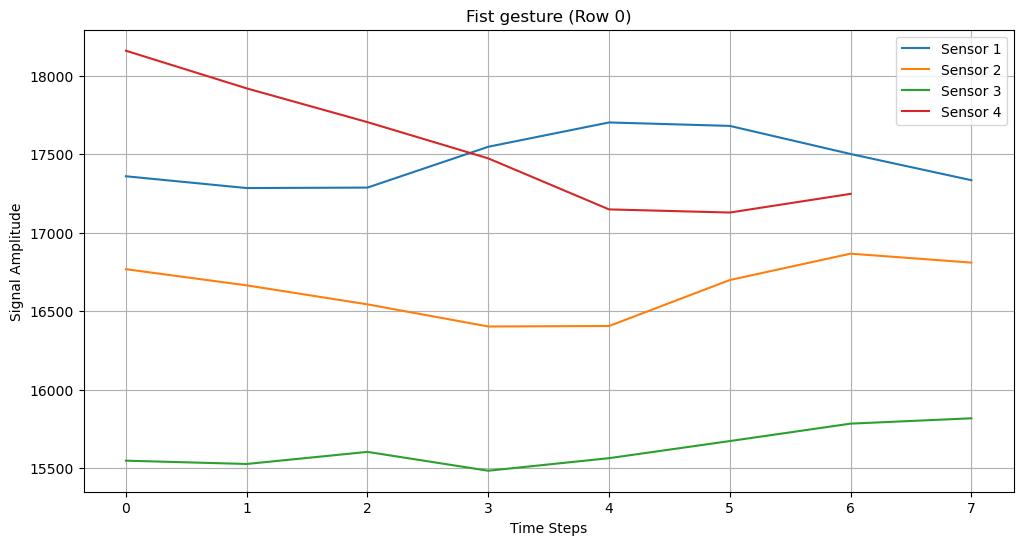

In [21]:
plot_time_signals(fist_df, row_index=0, title='Fist gesture')

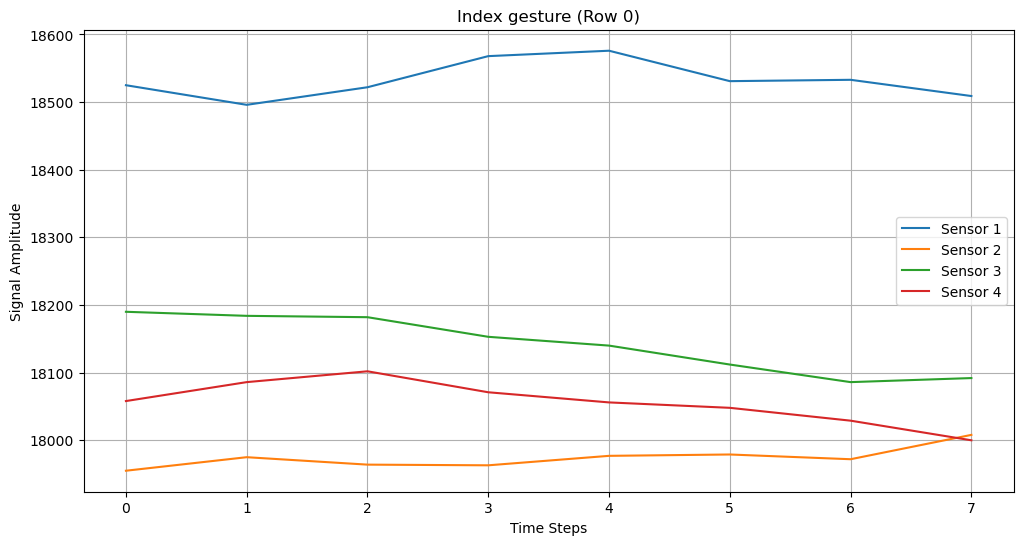

In [20]:
plot_time_signals(index_df, row_index=0, title='Index gesture')

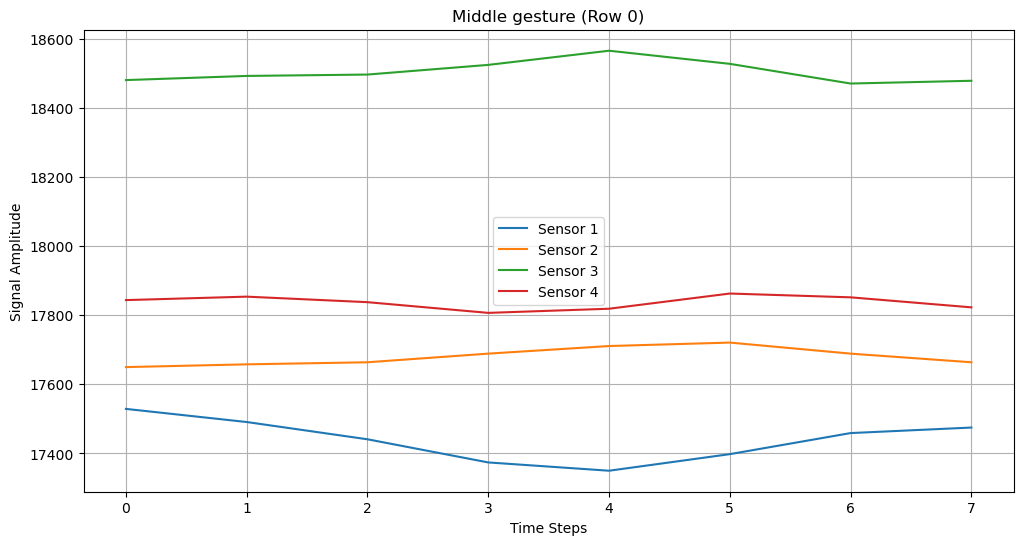

In [21]:
plot_time_signals(middle_df, row_index=0, title='Middle gesture')

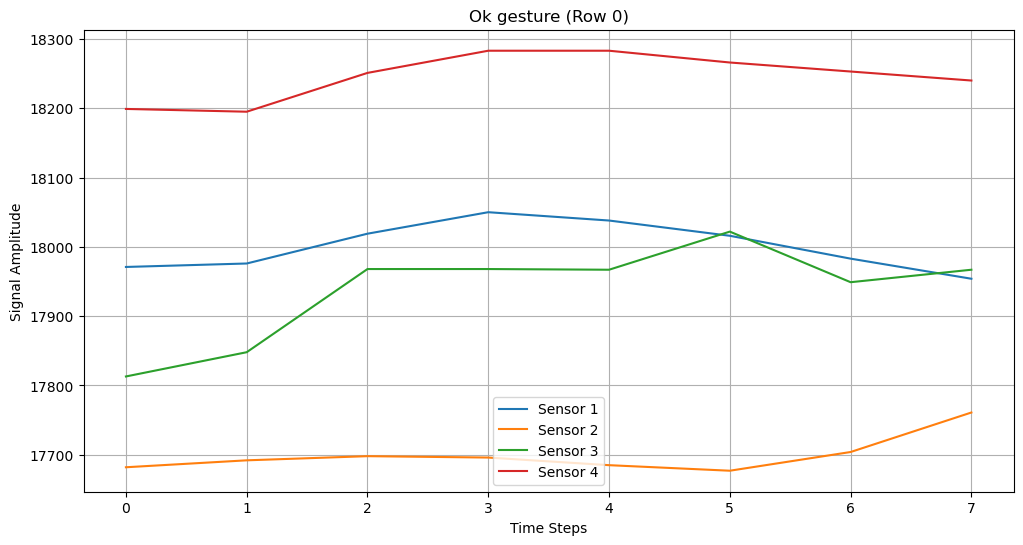

In [22]:
plot_time_signals(ok_df, row_index=0, title='Ok gesture')

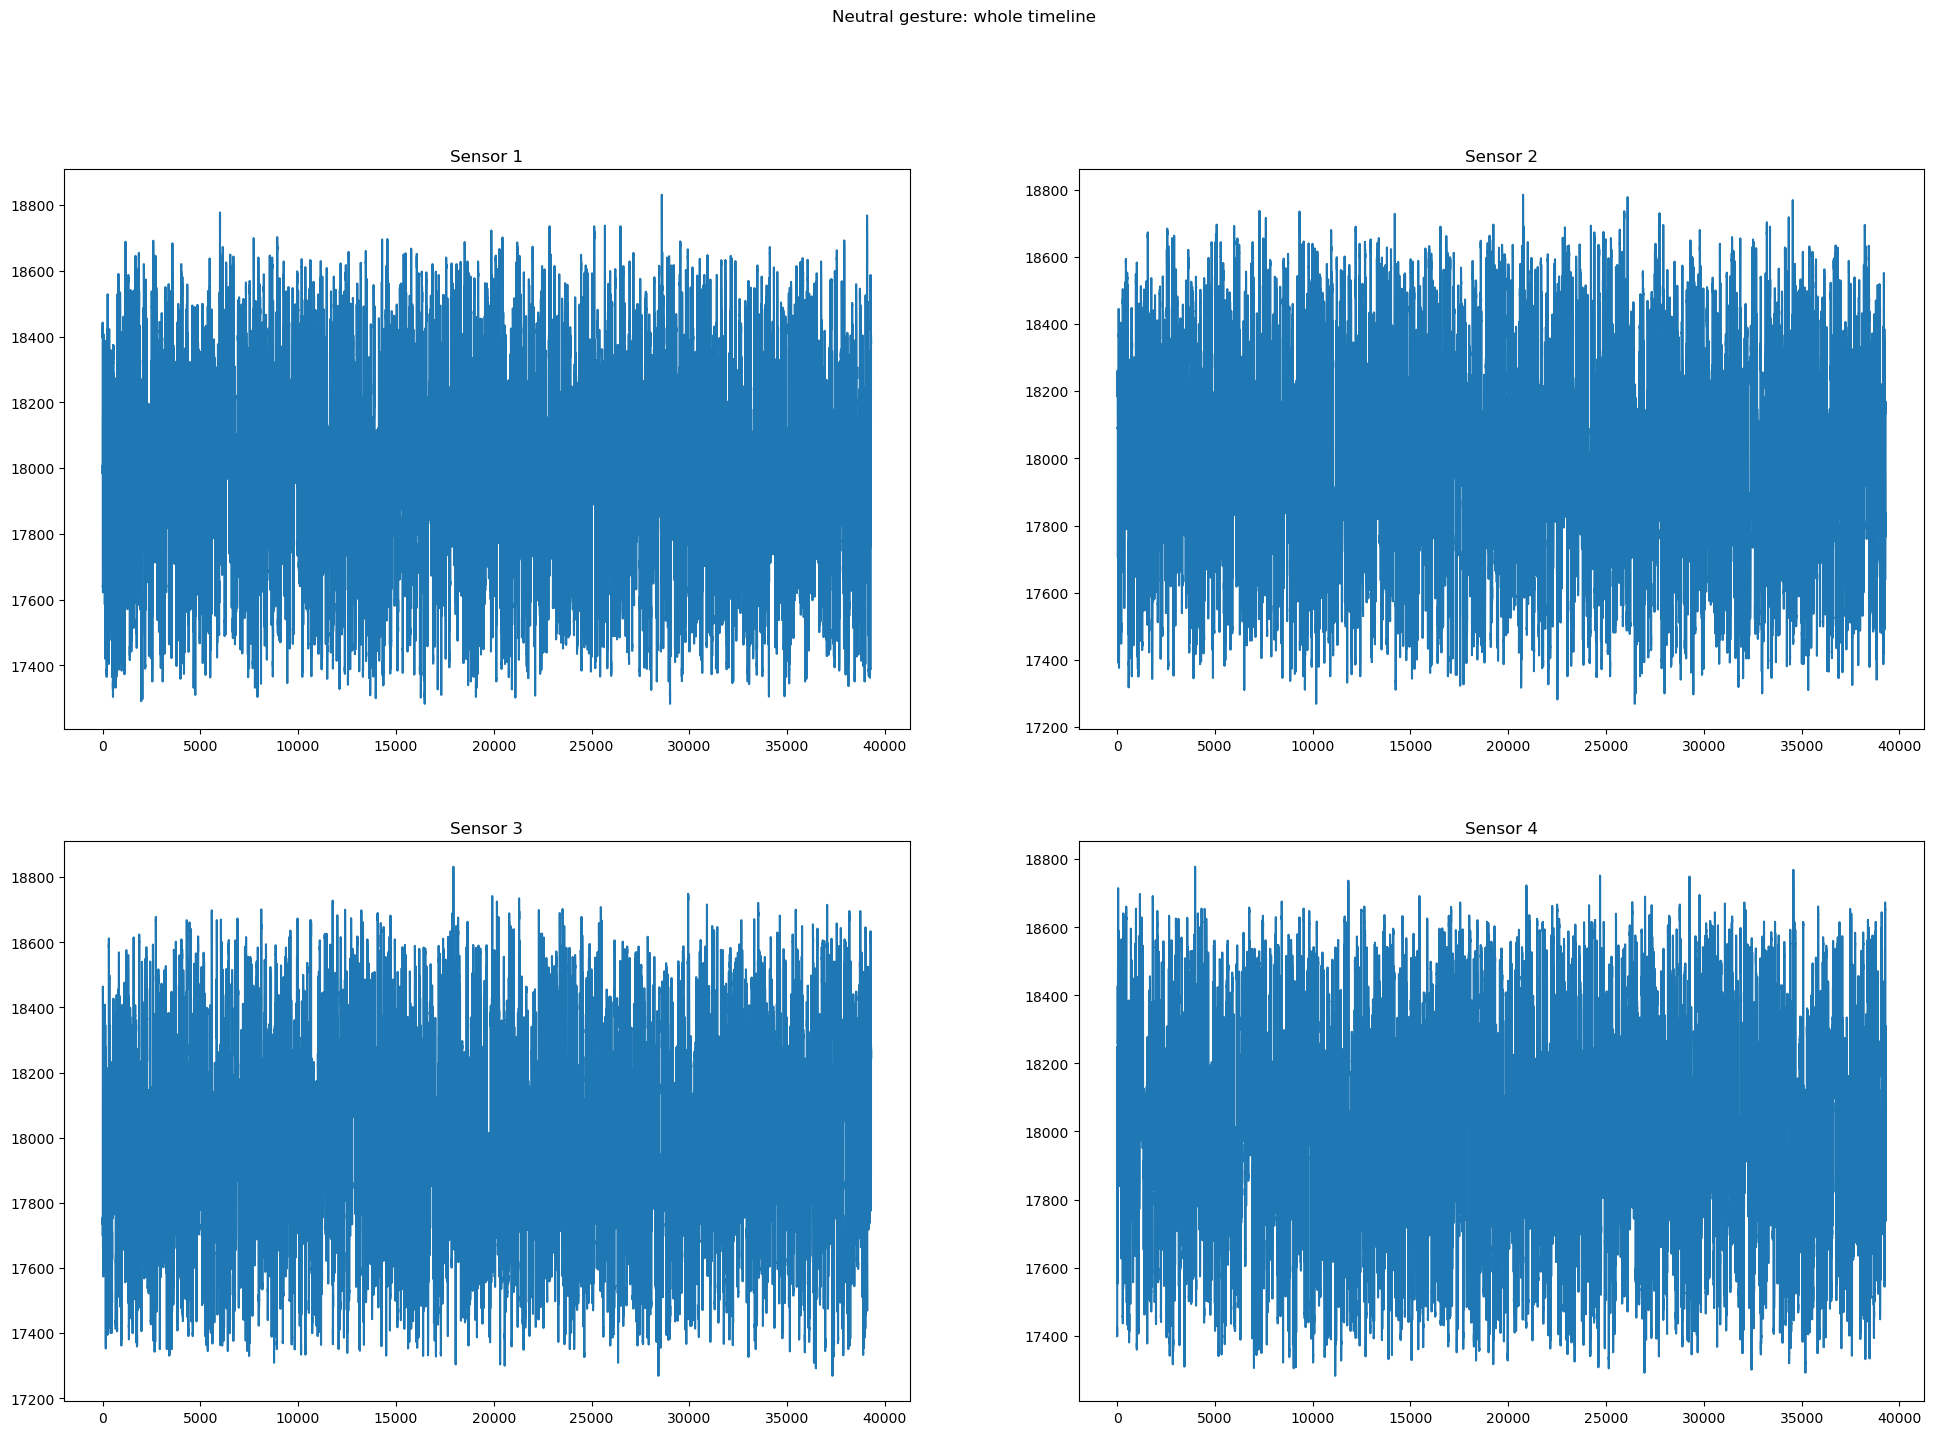

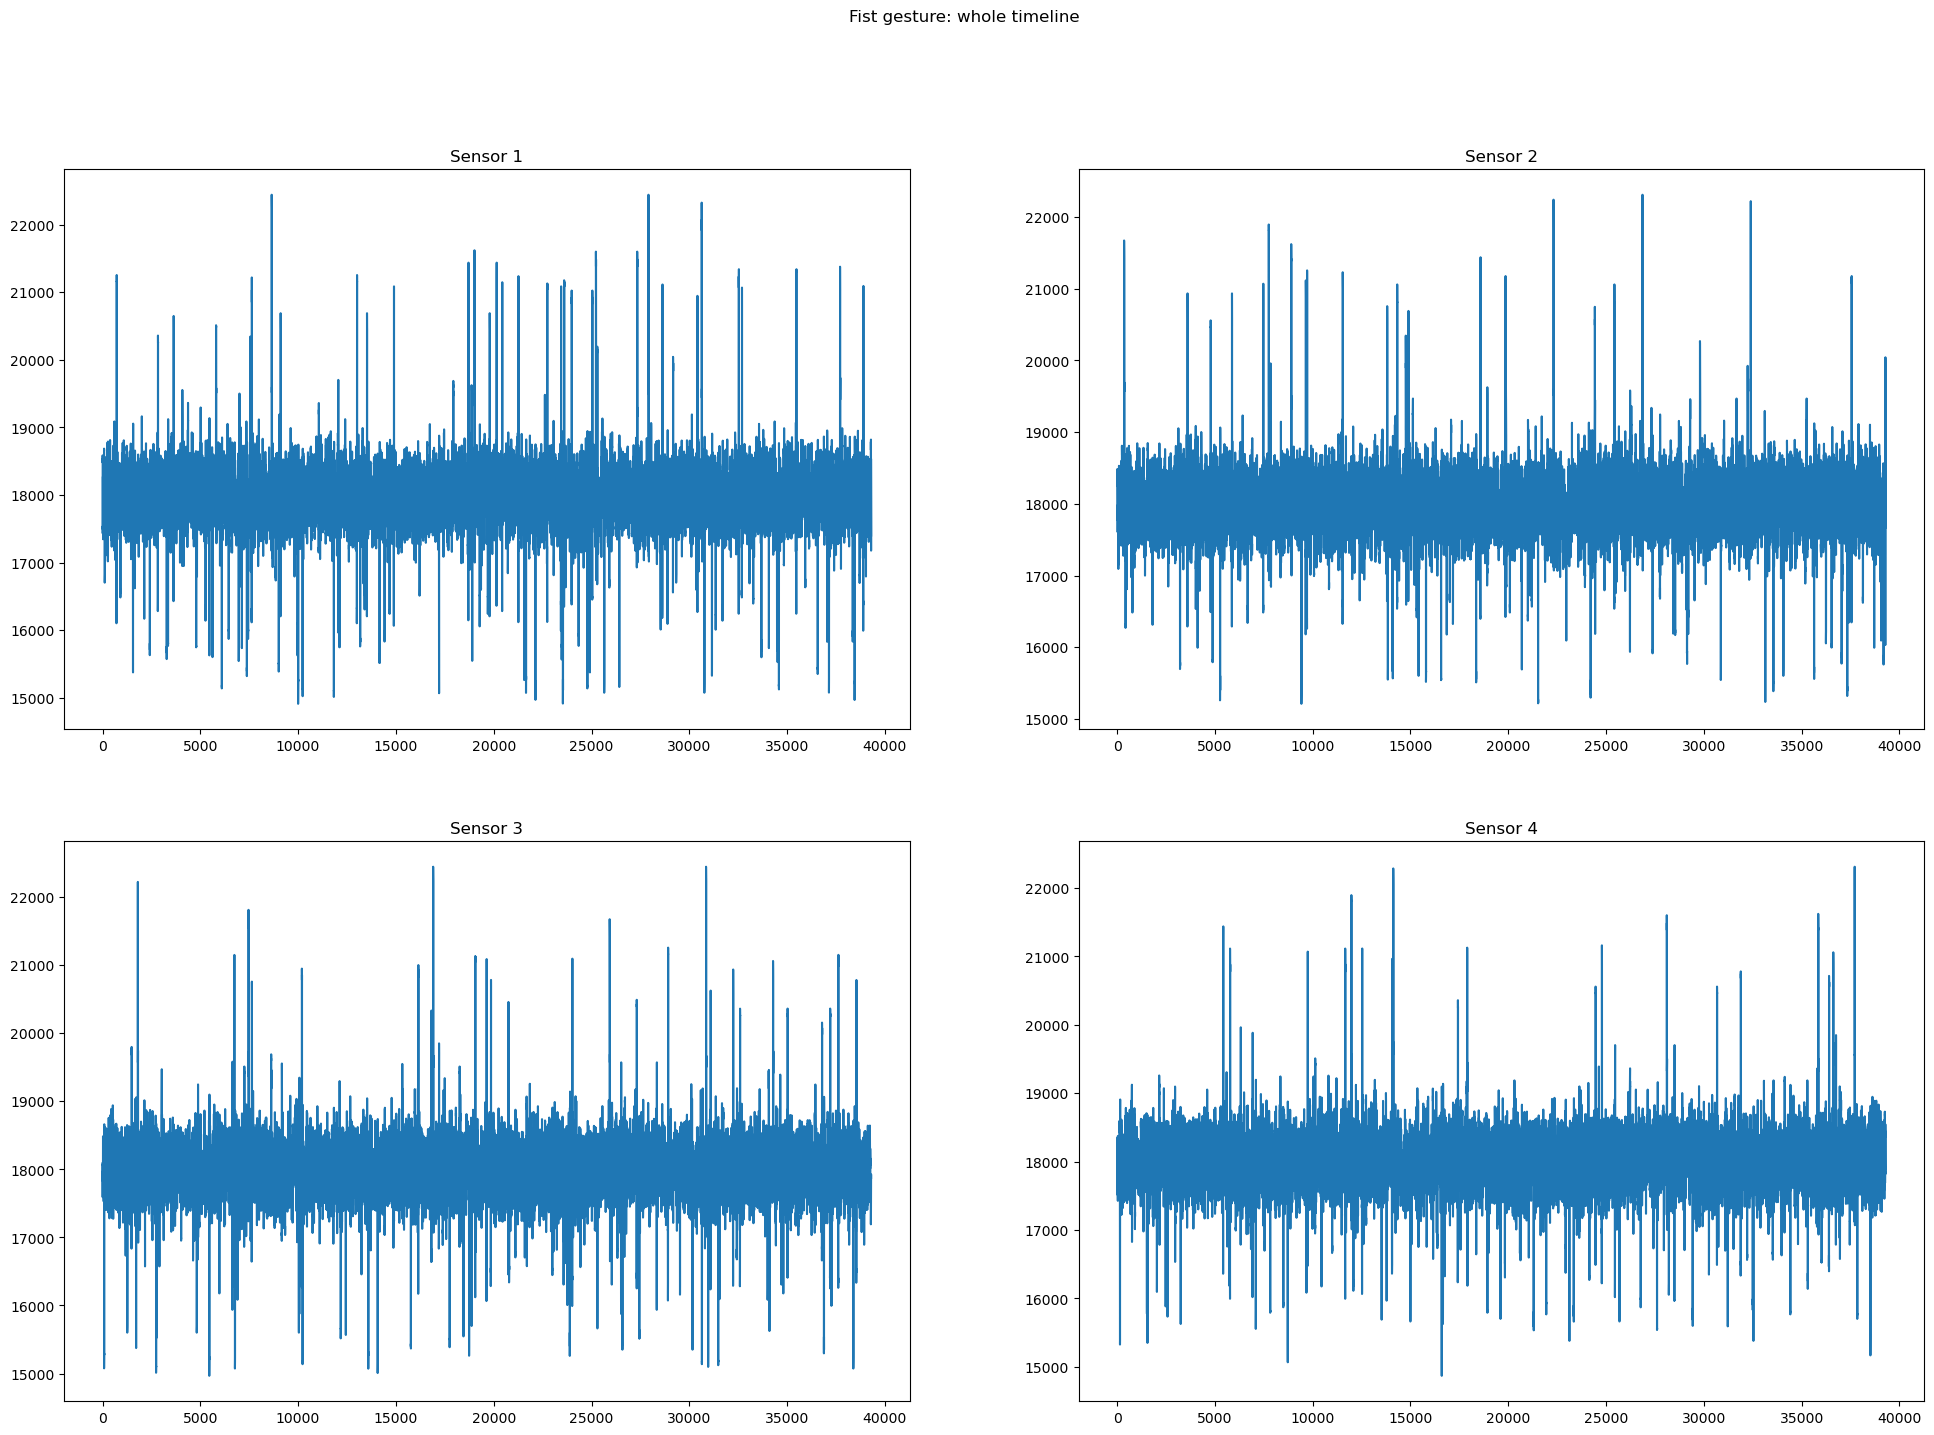

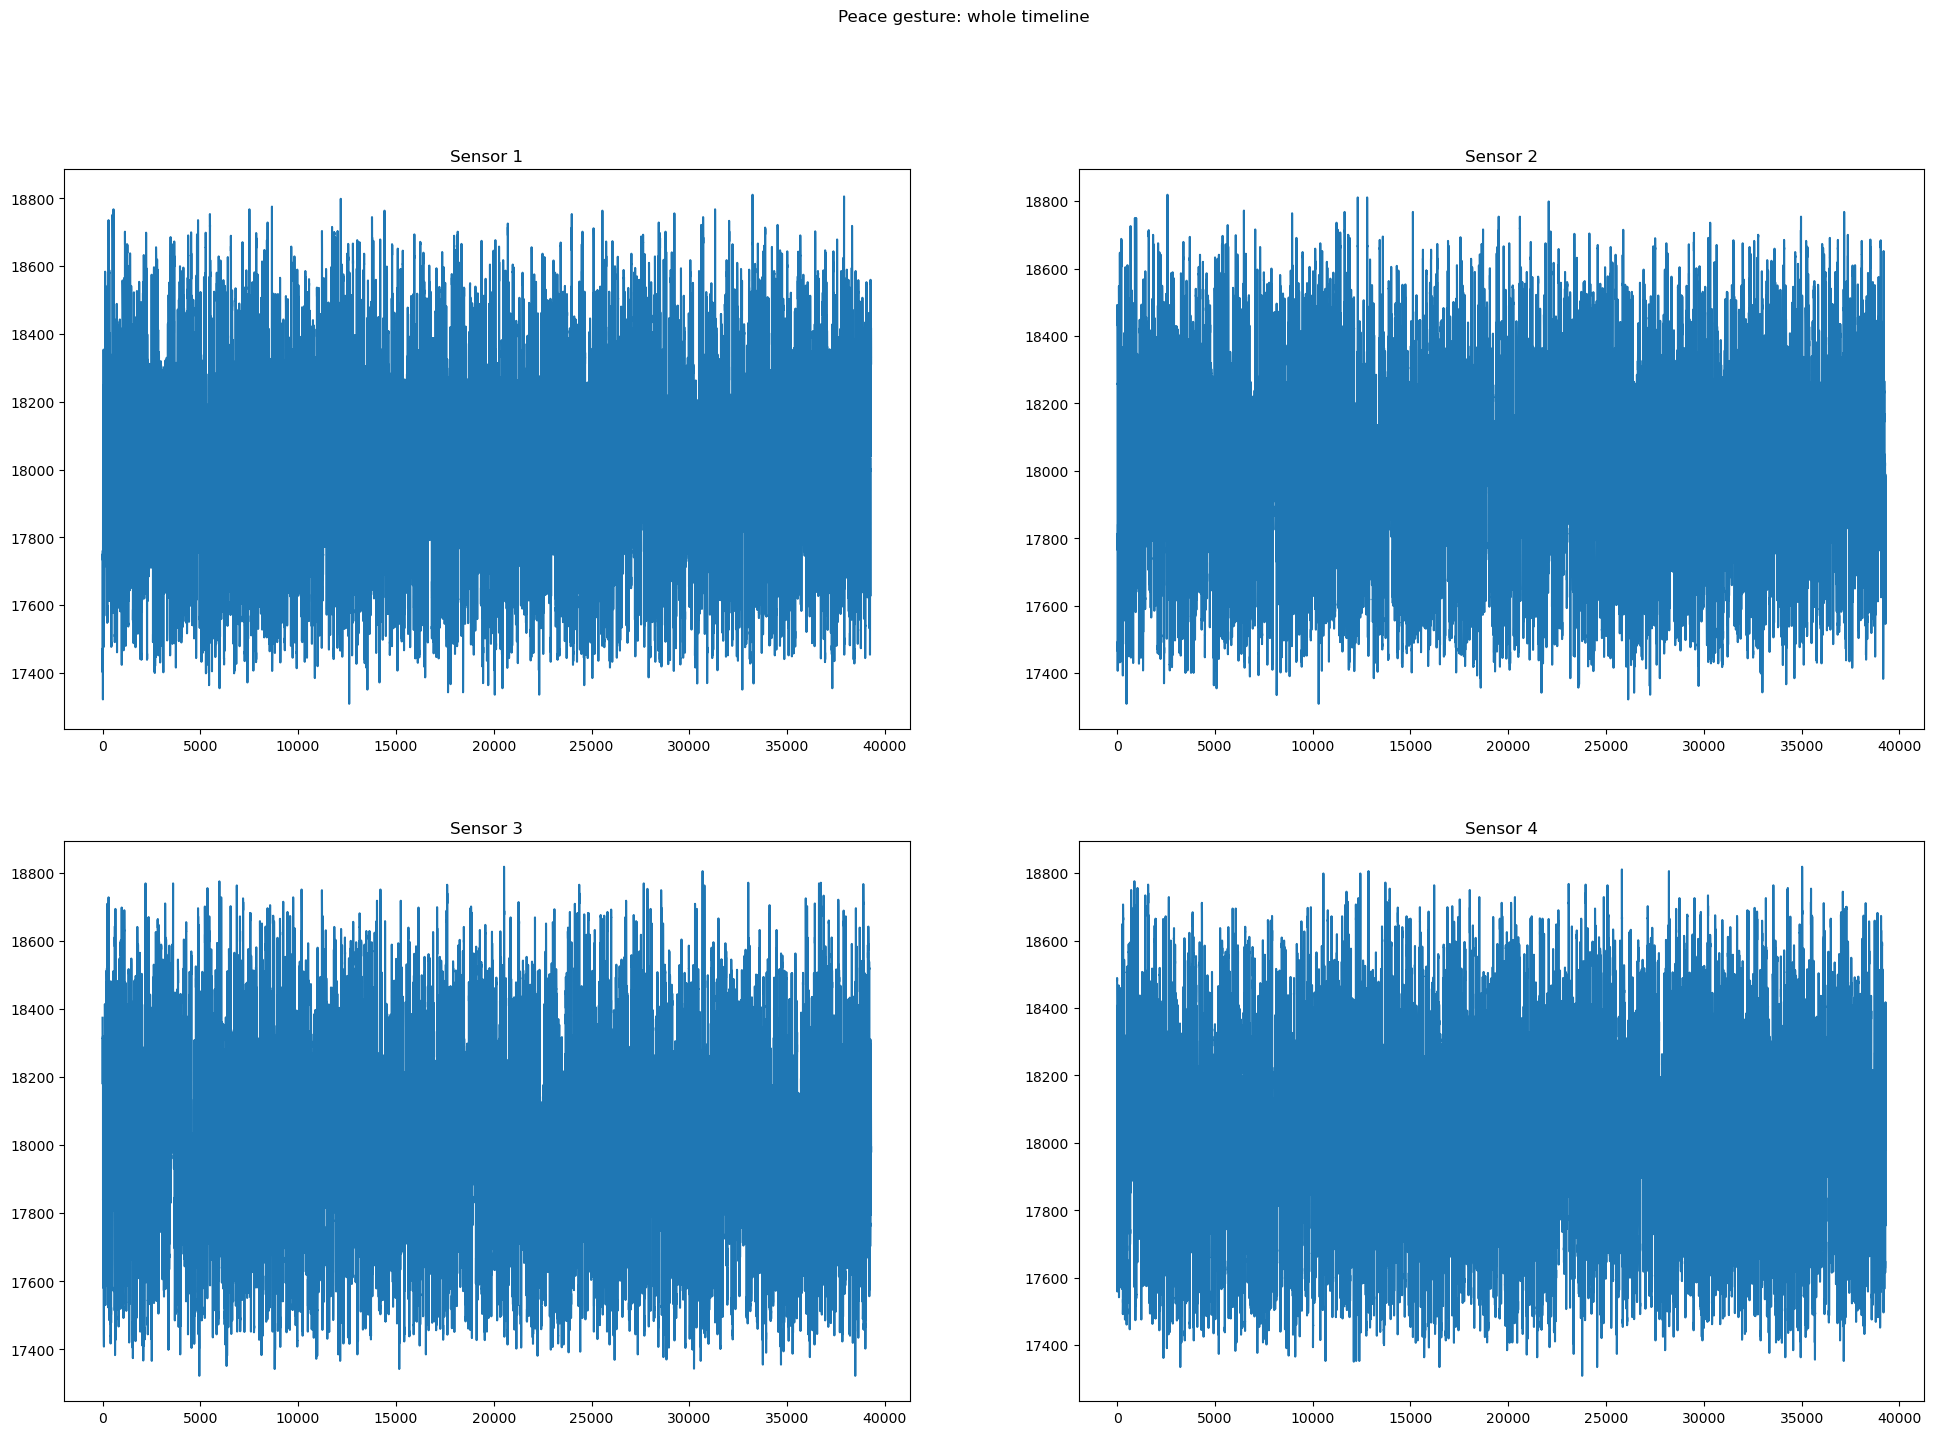

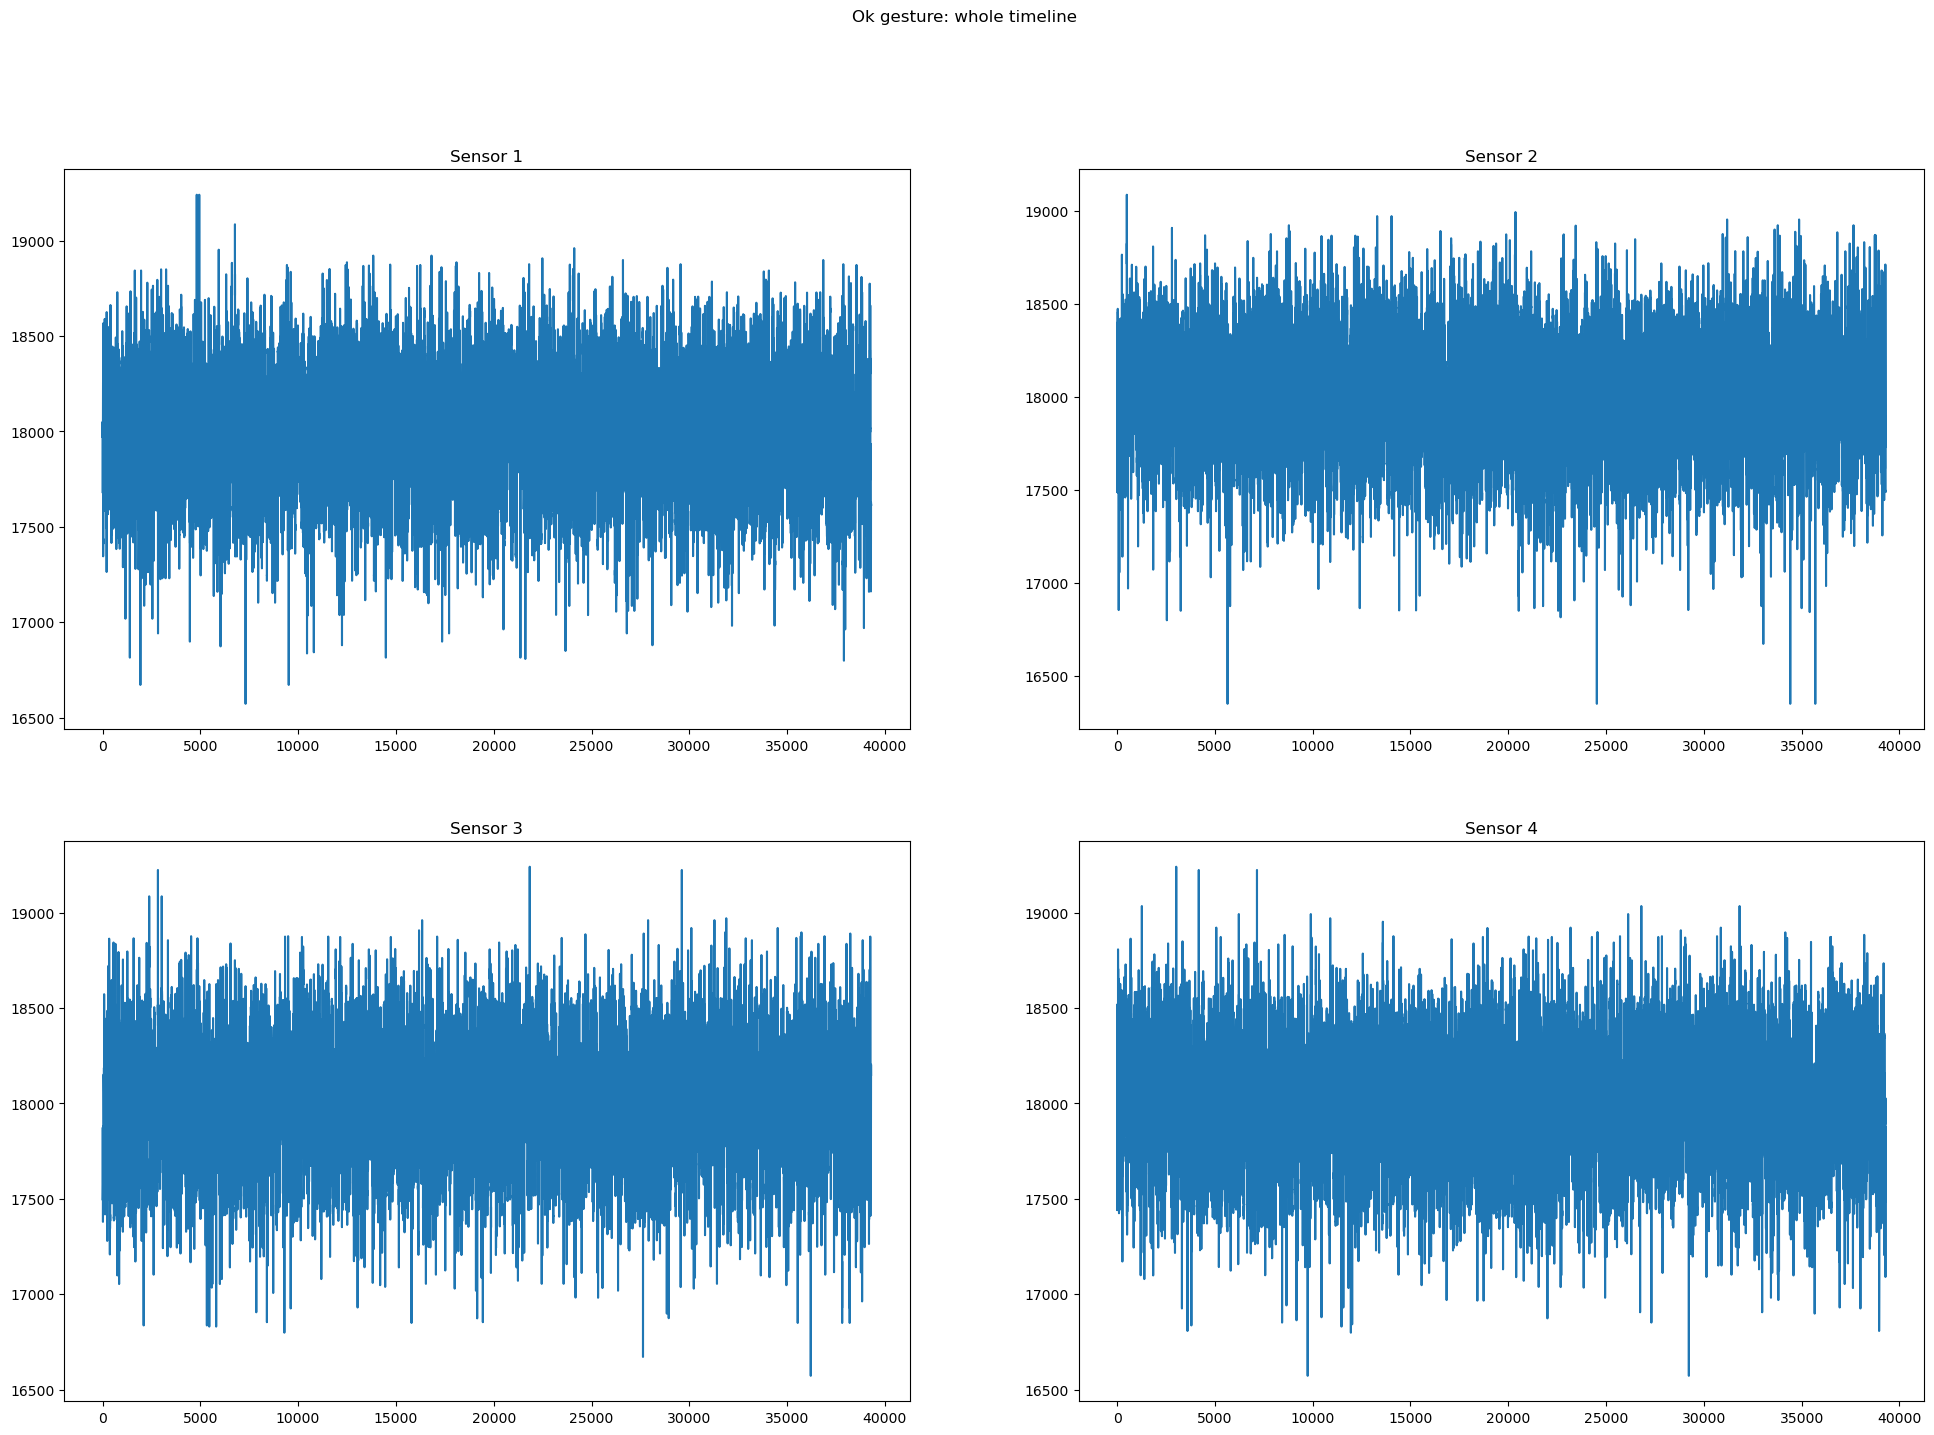

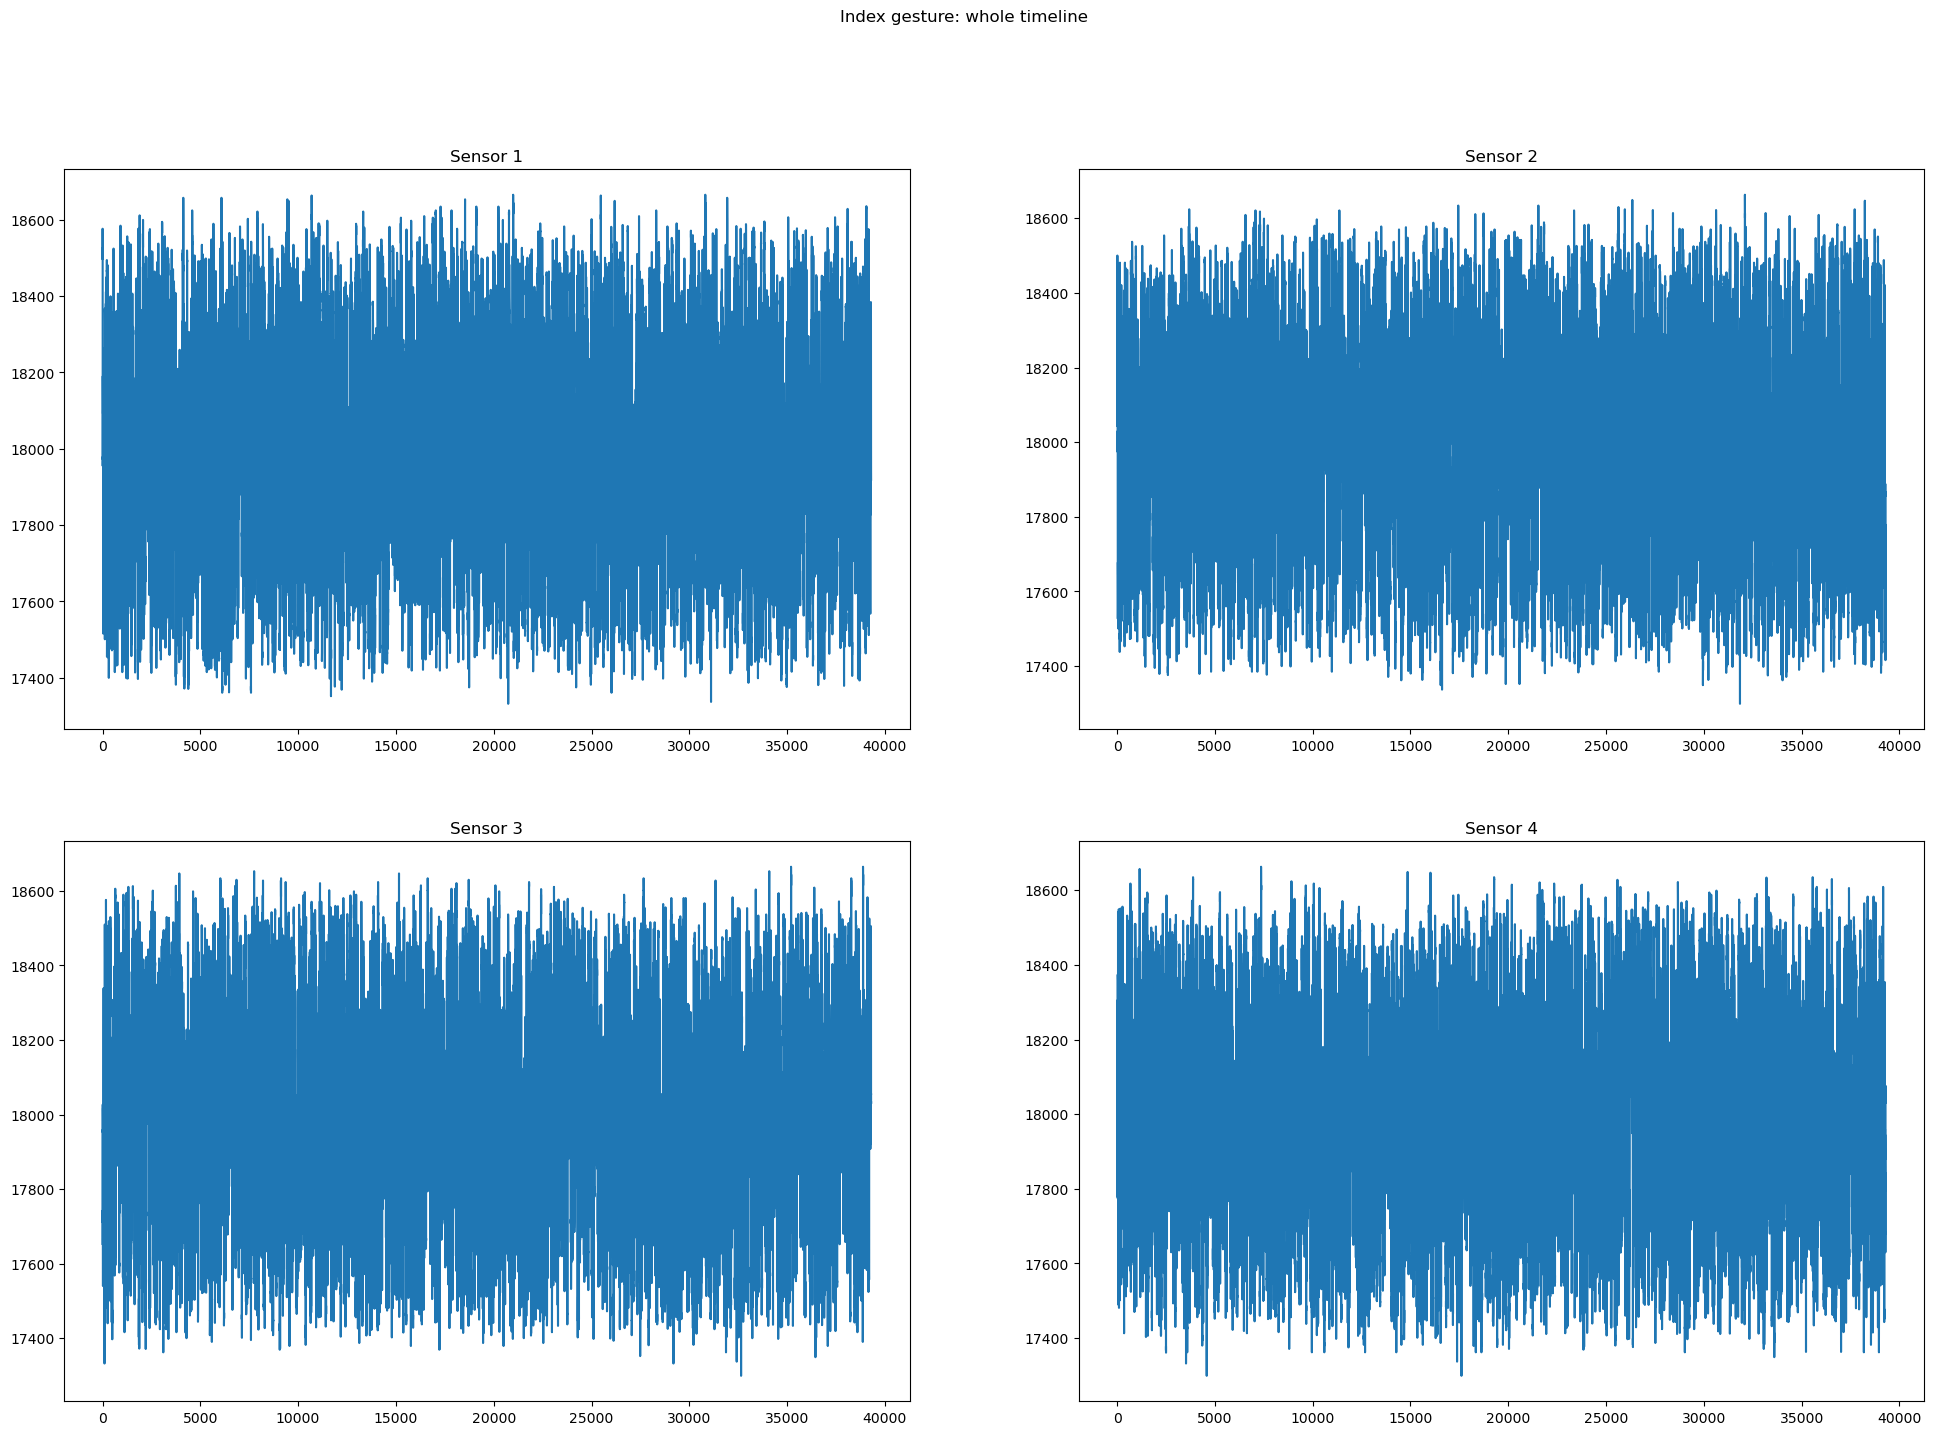

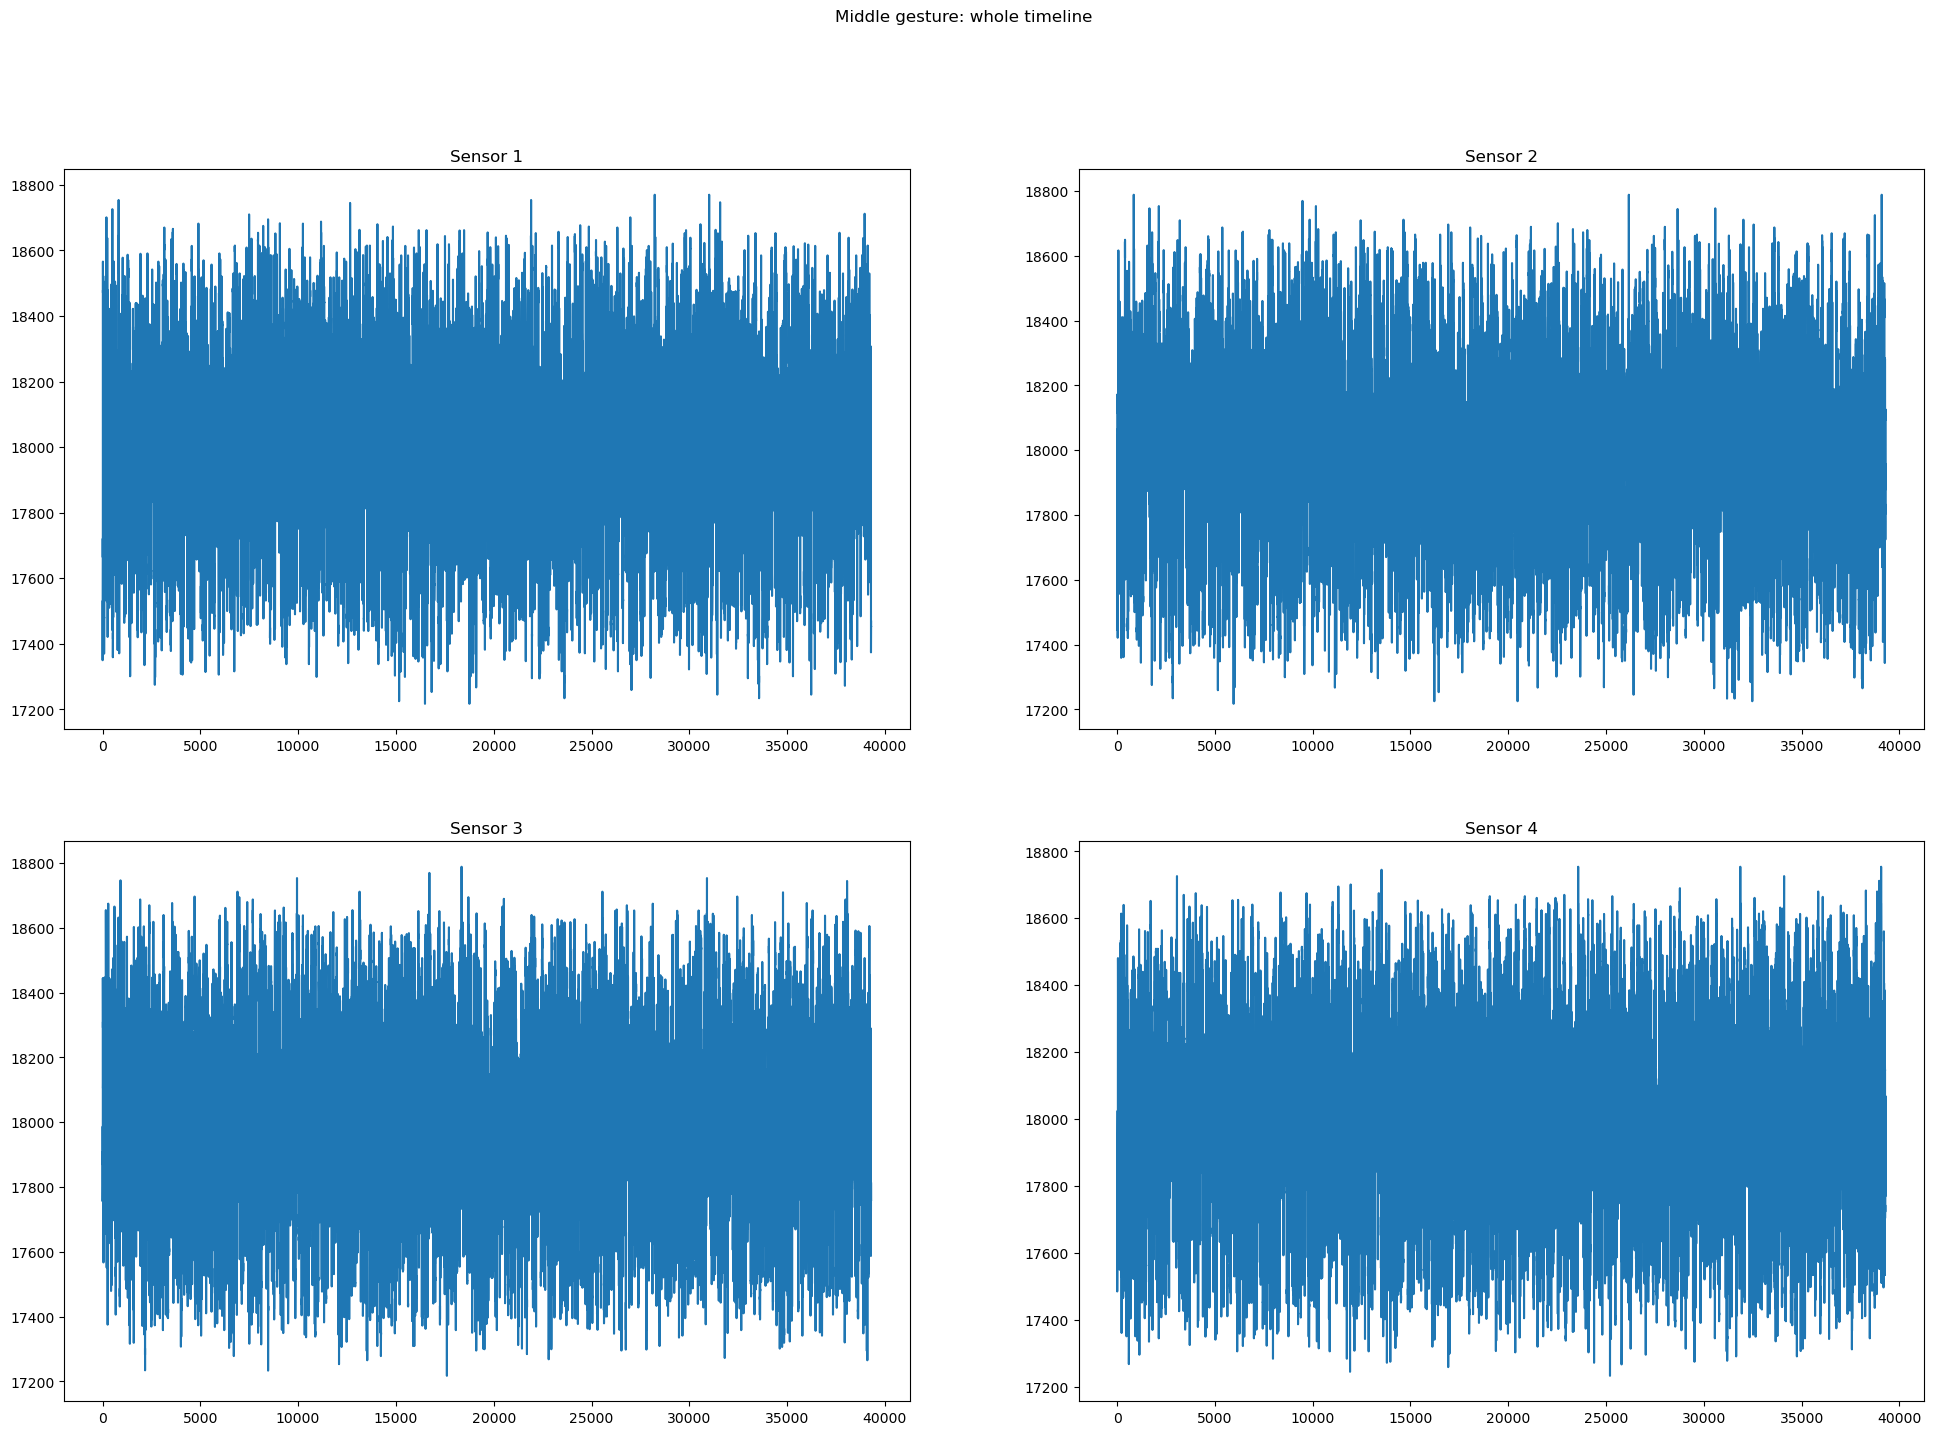

In [ ]:
if plot_all_timeline:
    plot_all_time_signals(fist_df, title='Fist gesture: whole timeline')
    plot_all_time_signals(peace_df, title='Peace gesture: whole timeline')
    plot_all_time_signals(ok_df, title='Ok gesture: whole timeline')
    plot_all_time_signals(index_df, title='Index gesture: whole timeline')
    plot_all_time_signals(middle_df, title='Middle gesture: whole timeline')

## Preprocessing pipeline tuning

Baseline signal provided
Baseline noise:  0.3833046908861373
Baseline noise:  0.38372745433189287
Baseline noise:  0.3845380643450469
Baseline noise:  0.3846271318923124


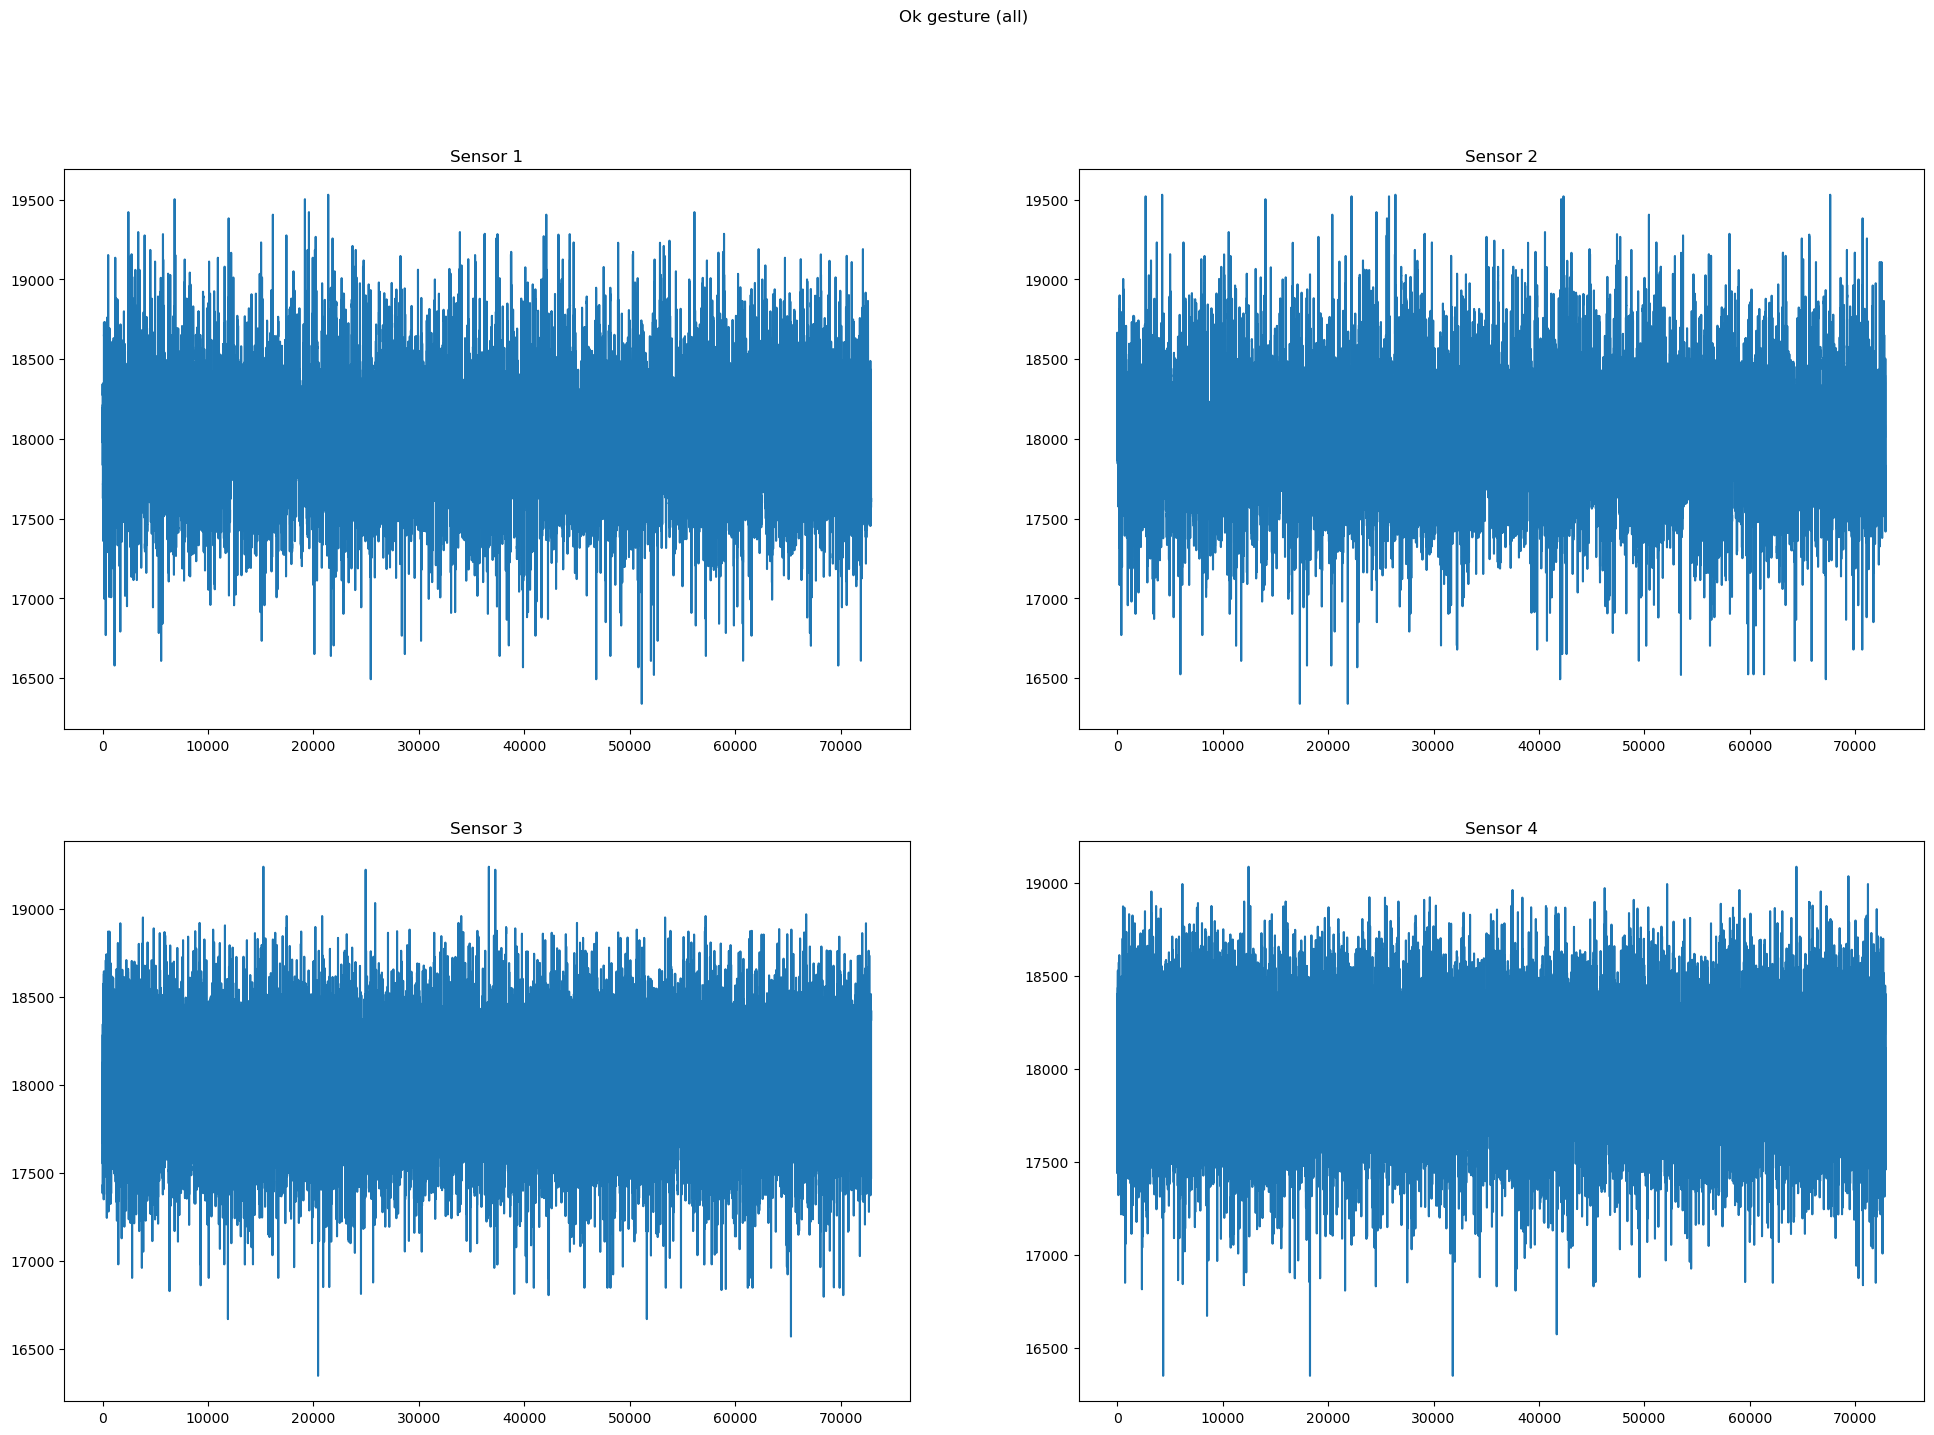

Raw SNR:  22.407422182432867
<class 'numpy.ndarray'>
Processed SNR:  3.866441888932602
Raw SNR:  22.403938849044597
<class 'numpy.ndarray'>
Processed SNR:  3.8968247697937928
Raw SNR:  22.390080489106182
<class 'numpy.ndarray'>
Processed SNR:  3.784297397931056
Raw SNR:  22.388367258824285
<class 'numpy.ndarray'>
Processed SNR:  3.7947394799610956


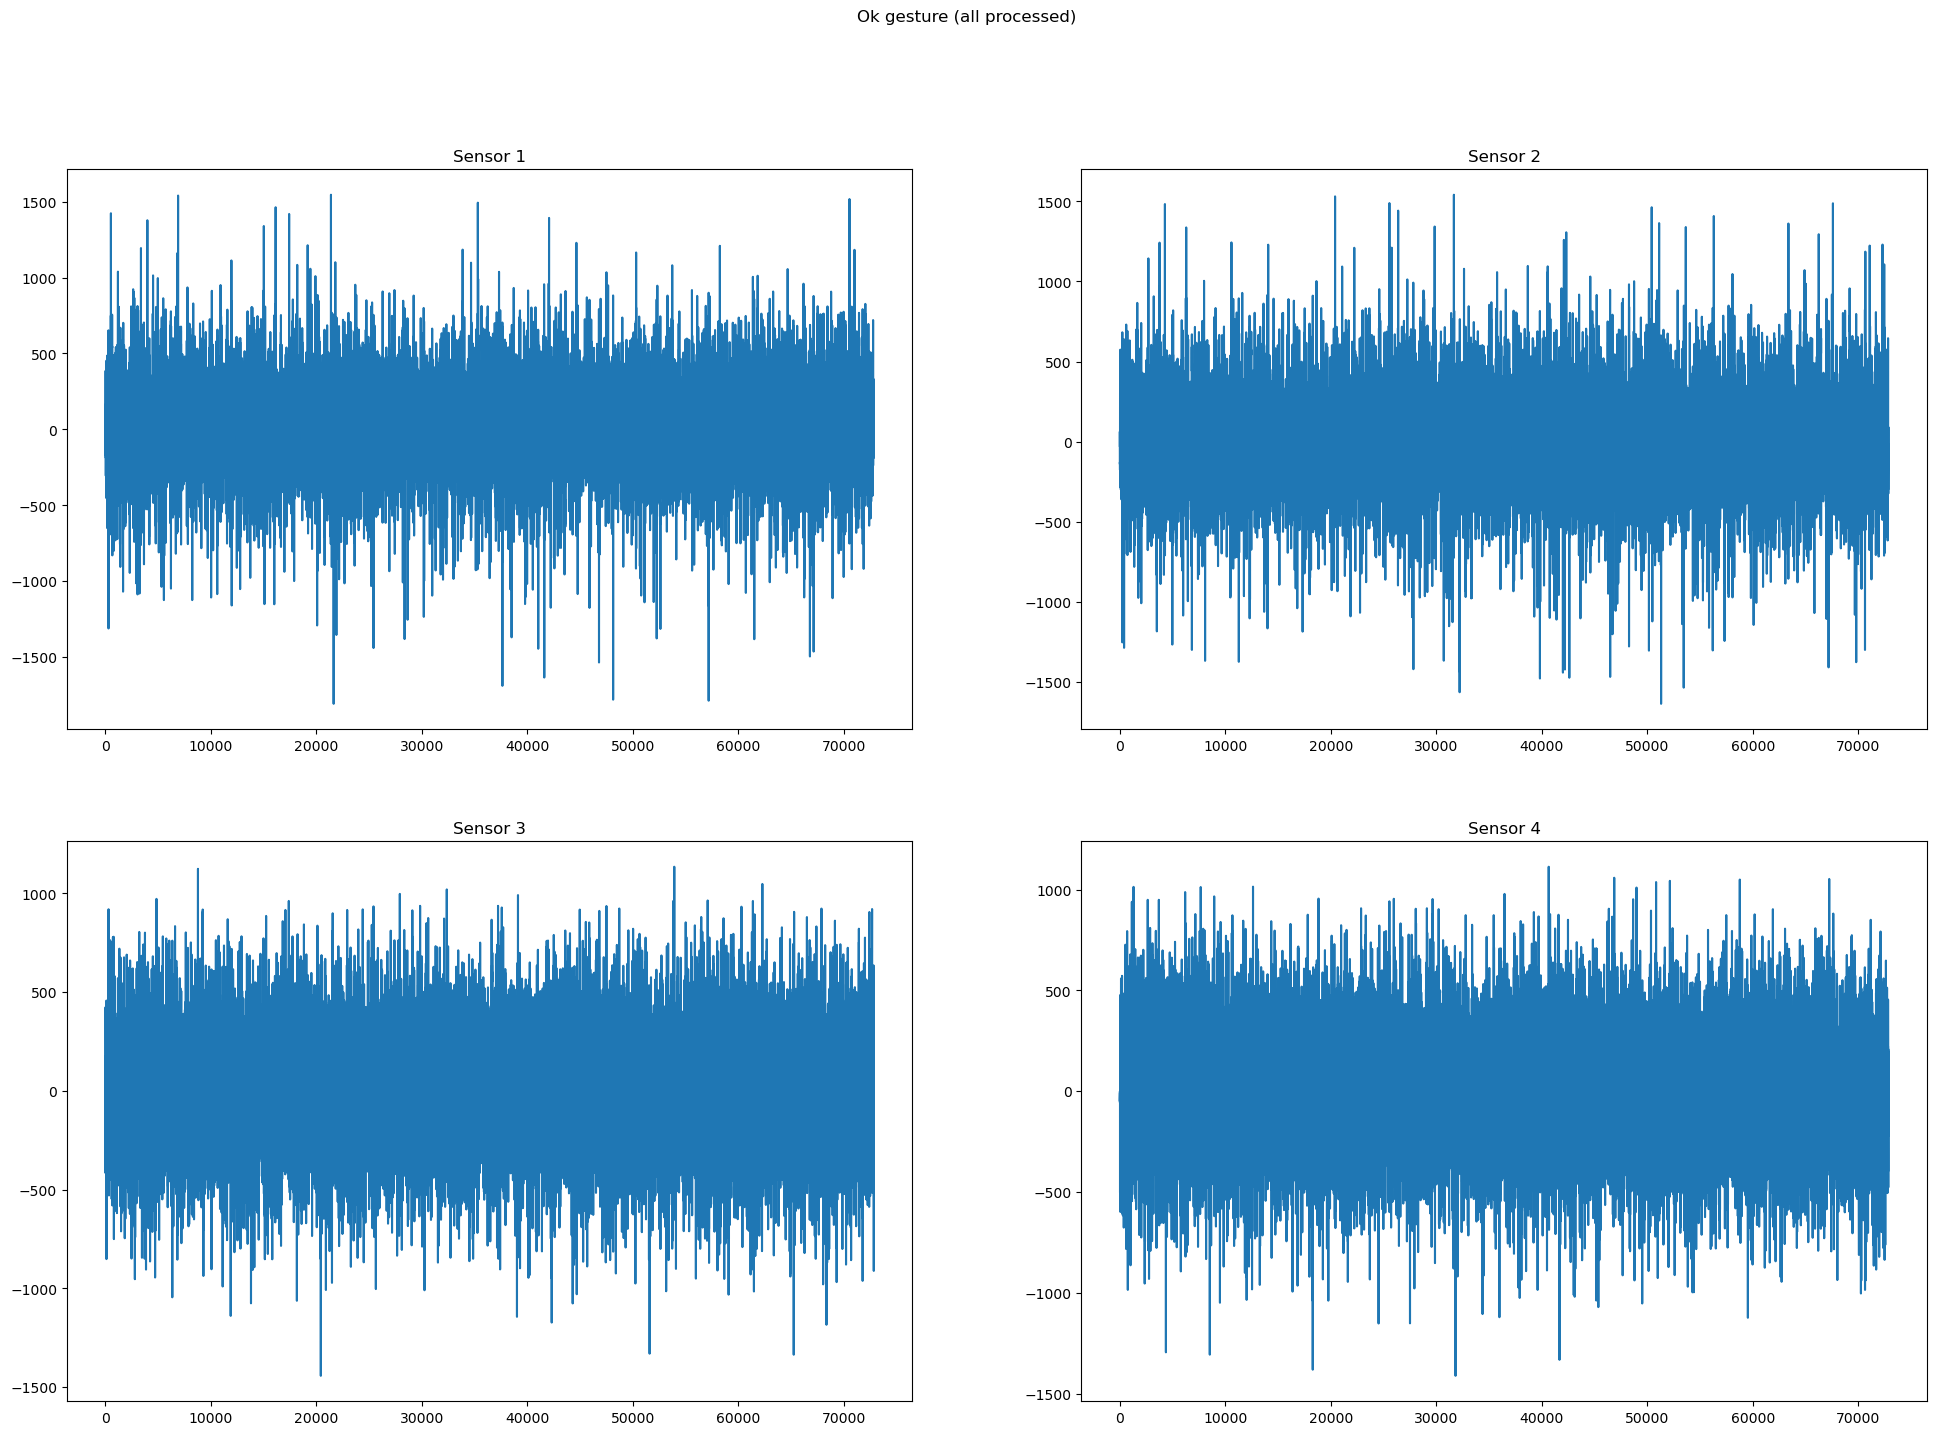

In [176]:
def plot_signal(data, row_index, title):
    # Split the row into 8 groups corresponding to sensors
    signals = np.array_split(data, num_sensors)

    # Plot each sensor's signal
    plt.figure(figsize=(12, 6))
    for i, signal in enumerate(signals):
        plt.plot(signal, label=f'Sensor {i + 1}')
    
    plt.title(f"{title} (Row {row_index})")
    plt.xlabel("Time Steps")
    plt.ylabel("Signal Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_all_signals(preprocessor, all_data, title, filter=False): 
    # Plot each sensor's signal
    signals = np.array_split(all_data, num_sensors)
    fig, axs = plt.subplots(2, 2, figsize=(24, 16))
    axs = axs.flatten()
    for sensor in range(0, num_sensors):
        sigs = signals[sensor]
        sigs = np.array(sigs).flatten()
        # mean = np.mean(sigs, axis=0)
        # std = np.std(sigs, axis=0)
        # sigs = (sigs - mean) #/ std
        if filter:
            print('Raw SNR: ', preprocessor.signaltonoise(sigs, sensor))
            sigs = preprocessor.preprocess(sigs, sensor)
            print('Processed SNR: ', preprocessor.signaltonoise(sigs, sensor))

        axs[sensor].set_title(f'Sensor {sensor + 1}')
        axs[sensor].plot(sigs)
    fig.suptitle(title)
    
    plt.show()

# index = 3
# raw_signal = fist_df.iloc[index, :-1].values
# plot_signal(raw_signal, row_index=index, title='Fist gesture')
# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.values, filter_type='band', library='scipy')
# proc_data = preprocessor.preprocess(raw_signal)
# plot_signal(proc_data, row_index=index, title='Fist gesture (processed)')

# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='highlow', library='scipy')
# raw_signal = fist_df.iloc[:, :-1].values
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all processed)', filter=True)
# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='band', library='scipy')
# raw_signal = fist_df.iloc[:, :-1].values
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all processed)', filter=True)

# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, baseline_array.flatten(), filter_type='highlow', library='libemg')
# raw_signal = ok_df.values
# plot_all_signals(preprocessor, raw_signal, title='Ok gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Ok gesture (all processed)', filter=True)

preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, baseline_array.flatten(), filter_type='band', library='libemg')
raw_signal = ok_df.values
plot_all_signals(preprocessor, raw_signal, title='Ok gesture (all)', filter=False)
plot_all_signals(preprocessor, raw_signal, title='Ok gesture (all processed)', filter=True)

# # preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='highlow', library='libemg')
# raw_signal = fist_df.iloc[:, :-1].values
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all processed)', filter=True)

# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='band', library='libemg')
# raw_signal = fist_df.iloc[:, :-1].values
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all processed)', filter=True)

## Class distribution

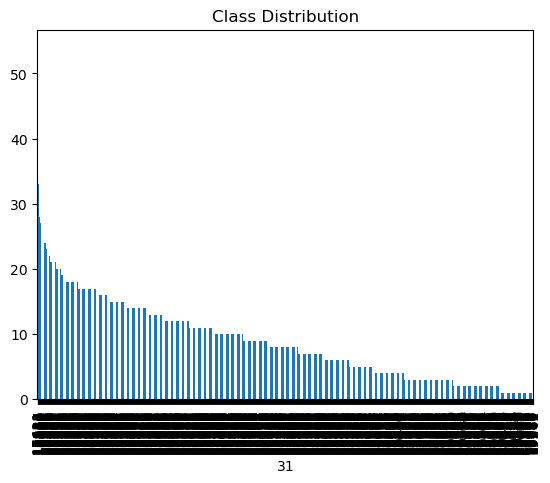

In [22]:
df.iloc[:, -1].value_counts().plot(kind='bar', title="Class Distribution")
plt.show()

## Sensor correlation analysis

/tmp/ipykernel_178670/515862046.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  sensor_means = sensor_data.groupby(np.arange(sensor_data.shape[1]) // 8, axis=1).mean()


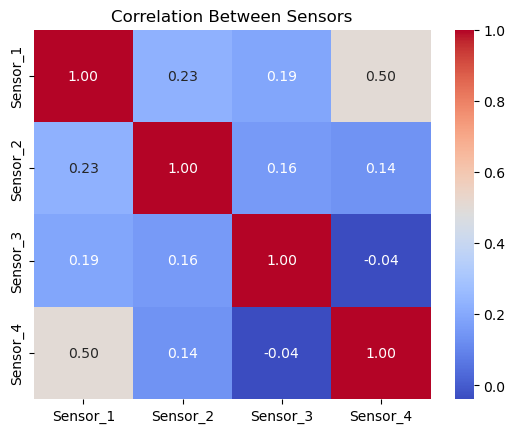

In [135]:
sensor_means = sensor_data.groupby(np.arange(sensor_data.shape[1]) // 8, axis=1).mean()

sensor_means.columns = [f"Sensor_{i+1}" for i in range(4)]

correlation = sensor_means.corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Sensors")
plt.show()

## Dimensionality Reduction

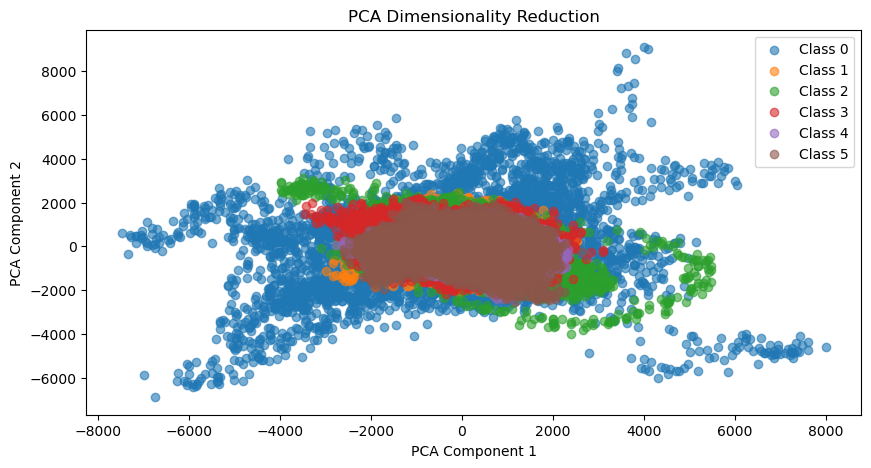

In [136]:
# PCA Dimensionality Reduction to 2 components
pca = PCA(n_components=2)
shape = sensor_data.shape
signals = np.array_split(sensor_data.values.flatten(), num_sensors)
for sensor in range(0, num_sensors):
    sigs = signals[sensor]
    sigs = np.array(sigs).flatten()
    sigs = preprocessor.preprocess(sigs, sensor)
    signals[sensor] = sigs

sensor_preproc = np.asarray(signals).flatten().reshape(shape)
pca_result = pca.fit_transform(sensor_preproc)

# Plot PCA results
plt.figure(figsize=(10, 5))
for class_id in np.unique(labels):
    plt.scatter(pca_result[labels == class_id, 0], pca_result[labels == class_id, 1], label=f'Class {class_id}', alpha=0.6)
plt.title("PCA Dimensionality Reduction")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

# # t-SNE Dimensionality Reduction to 2 components
# tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# tsne_result = tsne.fit_transform(sensor_preproc)

# # Plot t-SNE results
# plt.figure(figsize=(10, 5))
# for class_id in np.unique(labels):
#     plt.scatter(tsne_result[labels == class_id, 0], tsne_result[labels == class_id, 1], label=f'Class {class_id}', alpha=0.6)
# plt.title("t-SNE Dimensionality Reduction")
# plt.xlabel("t-SNE Component 1")
# plt.ylabel("t-SNE Component 2")
# plt.legend()
# plt.show()

## Data Preprocessing

## Spectal Analysis

In [80]:
preprocess = True

def spectral_analysis_overall(dataframe):
    time_steps_per_sensor = dataframe.shape[1] // num_sensors

    # Separate gesture class and sensor data
    gesture_classes = dataframe.iloc[:, -1]
    sensor_data = dataframe.iloc[:, :-1]
    
    # Prepare to store FFT results for each sensor
    fft_results = {f'Sensor_{i+1}': [] for i in range(num_sensors)}

    # Loop over all rows and accumulate FFT results per sensor
    for index, row in sensor_data.iterrows():
        signals = np.array_split(row.values, num_sensors)
        for i, signal in enumerate(signals):
            if preprocess:
                signal = preprocess_data(signal)
            fft_result = np.abs(fft(signal))[:time_steps_per_sensor // 2]  # Positive frequencies only
            fft_results[f'Sensor_{i+1}'].append(fft_result)
    
    # Compute average FFT amplitude for each sensor
    avg_fft_results = {sensor: np.mean(fft_results[sensor], axis=0) for sensor in fft_results}

    # Plot average FFT for each sensor
    plt.figure(figsize=(15, 10))
    for sensor, avg_fft in avg_fft_results.items():
        freqs = fftfreq(time_steps_per_sensor, d=1/fs)[:time_steps_per_sensor // 2]  # Positive frequencies
        plt.plot(freqs, avg_fft, label=sensor)
    
    plt.title("Average Spectral Analysis for All Sensors")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Now analyze by gesture class
    unique_classes = np.unique(gesture_classes)
    plt.figure(figsize=(15, 10))
    for gesture_class in unique_classes:
        class_subset = dataframe[dataframe.iloc[:, -1] == gesture_class]
        class_fft_results = {f'Sensor_{i+1}': [] for i in range(num_sensors)}
        for _, row in class_subset.iloc[:, :-1].iterrows():
            signals = np.array_split(row.values, num_sensors)
            for i, signal in enumerate(signals):
                if preprocess:
                    signal = preprocess_data(signal)
                fft_result = np.abs(fft(signal))[:time_steps_per_sensor // 2]
                class_fft_results[f'Sensor_{i+1}'].append(fft_result)
        # Average across this class
        avg_class_fft = np.mean([np.mean(class_fft_results[sensor], axis=0) for sensor in class_fft_results], axis=0)
        freqs = fftfreq(time_steps_per_sensor, d=1/fs)[:time_steps_per_sensor // 2]
        plt.plot(freqs, avg_class_fft, label=f"Class {gesture_class}")

    plt.title("Average Spectral Analysis by Gesture Class")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

In [81]:
spectral_analysis_overall(df)

NameError: name 'preprocess_data' is not defined

In [137]:
preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, baseline_array.flatten(), filter_type='band', library='scipy')
preprocessor2 = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, baseline_array.flatten(), filter_type='band', library='libemg')
# preprocessor3 = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, baseline_array.flatten(), filter_type='band', library='nk2')

Baseline signal provided
Baseline noise:  0.3833046908861373
Baseline noise:  0.38372745433189287
Baseline noise:  0.3845380643450469
Baseline noise:  0.3846271318923124
Baseline signal provided
Baseline noise:  0.3833046908861373
Baseline noise:  0.38372745433189287
Baseline noise:  0.3845380643450469
Baseline noise:  0.3846271318923124


## Train networks

In [219]:
from libemg.utils import get_windows
from libemg.feature_extractor import FeatureExtractor

def preprocess_per_sensor(df, preprocessor, class_name, num_sensors=4, window_size=200, window_increment=100):
    raw_signal = df.values
    shape = raw_signal.shape
    signals = np.array_split(raw_signal.flatten(), num_sensors)
    for sensor in range(0, num_sensors):
        sigs = signals[sensor]
        sigs = np.array(sigs).flatten()
        sigs = preprocessor.preprocess(sigs, sensor)
        sigs = preprocessor2.preprocess(sigs, sensor)
        # sigs = preprocessor3.preprocess(sigs, sensor)
        signals[sensor] = sigs
    raw_signal = np.asarray(signals).flatten().reshape(shape)
    raw_signal = np.hstack((raw_signal[:, ::8], raw_signal[:, 1::8], raw_signal[:, 2::8], raw_signal[:, 3::8], raw_signal[:, 4::8], raw_signal[:, 5::8], raw_signal[:, 6::8], raw_signal[:, 7::8]))
    raw_signal = raw_signal.reshape(-1, num_sensors)
    raw_signal = get_windows(raw_signal, window_size=window_size, window_increment=window_increment)
    features_preshaped = raw_signal
    raw_signal = raw_signal.reshape(raw_signal.shape[0], -1)
    raw_signal = np.hstack((raw_signal, np.full((raw_signal.shape[0], 1), class_name)))
    return raw_signal, features_preshaped

def get_features_per_sensor(windows):
    fe = FeatureExtractor()
    # feature_list = fe.get_feature_list()
    # Extract a predefined feature group
    fe = FeatureExtractor()
    features_fist = fe.extract_feature_group('HTD', windows, array=True)
    print(features_fist)
    return features_fist


In [221]:
windows = [[] for _ in range(num_classes)]
fist_array, windows[Classes.FIST] = preprocess_per_sensor(fist_df, preprocessor, Classes.FIST)
index_array, windows[Classes.INDEX] = preprocess_per_sensor(index_df, preprocessor, Classes.INDEX)
middle_array, windows[Classes.MIDDLE] = preprocess_per_sensor(middle_df, preprocessor, Classes.MIDDLE)
ok_array, windows[Classes.OK] = preprocess_per_sensor(ok_df, preprocessor, Classes.OK)
peace_array, windows[Classes.PEACE] = preprocess_per_sensor(peace_df, preprocessor, Classes.PEACE)
thumb_array, windows[Classes.THUMB] = preprocess_per_sensor(thumb_df, preprocessor, Classes.THUMB)

features = [[] for _ in range(num_classes)]
for i in range(num_classes):
    features[i] = get_features_per_sensor(windows[i])

# we have 4 features per sensor, 4 sensors, and 6 classes
# with window size 200 and increment 100, we have 727 per feature
print(len(features[Classes.FIST]), len(features[Classes.INDEX]), len(features[Classes.MIDDLE]), len(features[Classes.OK]), len(features[Classes.PEACE]), len(features[Classes.THUMB]))
# fist_feat_array = features[Classes.FIST]['MAV'] # 727 x 4
fist_feat_array = np.hstack((features[Classes.FIST], np.full((features[Classes.FIST].shape[0], 1), Classes.FIST)))
print(fist_feat_array.shape)
index_feat_array = np.hstack((features[Classes.INDEX], np.full((features[Classes.INDEX].shape[0], 1), Classes.INDEX)))
middle_feat_array = np.hstack((features[Classes.MIDDLE], np.full((features[Classes.MIDDLE].shape[0], 1), Classes.MIDDLE)))
ok_feat_array = np.hstack((features[Classes.OK], np.full((features[Classes.OK].shape[0], 1), Classes.OK)))
peace_feat_array = np.hstack((features[Classes.PEACE], np.full((features[Classes.PEACE].shape[0], 1), Classes.PEACE)))
thumb_feat_array = np.hstack((features[Classes.THUMB], np.full((features[Classes.THUMB].shape[0], 1), Classes.THUMB)))
# fist_feat_array = np.hstack((fist_feat_array, np.full((len(fist_feat_array), 1), Classes.FIST)))
# print(fist_feat_array.shape)
    

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
[[  397.52437269   576.42768794   532.92368238 ... 39039.57390594
  36634.25326232 54266.15673161]
 [  407.29911194   491.42426135   494.35896551 ... 36090.09338485
  36417.7492872  52068.17477267]
 [  393.26712649   457.117511     488.62540216 ... 34024.26085464
  36773.39095237 48768.26637499]
 ...
 [  303.80372368   260.39666285   460.2689947  ... 24622.00217326
  32031.70498248 30062.13311237]
 [  291.93705697   228.

In [222]:
X = np.vstack((fist_array[:, :-1], index_array[:, :-1], middle_array[:, :-1], ok_array[:, :-1], peace_array[:, :-1], thumb_array[:, :-1]))
y = np.vstack((fist_array[:, -1][:, np.newaxis], index_array[:, -1][:, np.newaxis], middle_array[:, -1][:, np.newaxis], ok_array[:, -1][:, np.newaxis], peace_array[:, -1][:, np.newaxis], thumb_array[:, -1][:, np.newaxis])).squeeze()

X_feat = np.vstack((fist_feat_array[:, :-1], index_feat_array[:, :-1], middle_feat_array[:, :-1], ok_feat_array[:, :-1], peace_feat_array[:, :-1], thumb_feat_array[:, :-1]))
y_feat = y

In [224]:
print(X.shape, y.shape)
X_feat.shape, y_feat.shape

(4362, 800) (4362,)


((4362, 16), (4362,))

In [225]:
X.max(), X.min()
X_feat.max(), X_feat.min()

(60769.020029373256, 5.0)

In [226]:
from sklearn.preprocessing import MinMaxScaler
# scaler= RobustScaler()
scaler = StandardScaler()
# scaler = MinMaxScaler()

X = scaler.fit_transform(X)
X_feat = scaler.fit_transform(X_feat)

In [144]:
with open("custom_scaler_transformed_features.pkl", "wb") as f:
    dump(scaler, f, protocol=5)

In [227]:
X.max(), X.min()
X_feat.max(), X_feat.min()

(5.608413757673872, -4.319829783568406)

In [228]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
X_train_feat, X_test_feat, y_train_feat, y_test_feat = train_test_split(X_feat, y_feat, test_size=0.2, shuffle=True, random_state=42)

In [229]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape
X_train_feat.shape, X_test_feat.shape, y_train_feat.shape, y_test_feat.shape

((3489, 16), (873, 16), (3489,), (873,))

In [231]:
# Count classes in y_test
unique, counts = np.unique(y_test, return_counts=True)
unique, counts

(array([0., 1., 2., 3., 4., 5.]), array([163, 149, 151, 147, 121, 142]))

## Classical models

In [233]:
clf = RandomForestClassifier(n_estimators=100, max_features='sqrt', max_depth=100, random_state=42)
# clf.fit(X_train, y_train)
clf.fit(X_train_feat, y_train_feat)

RandomForestClassifier(max_depth=100, random_state=42)

In [234]:
depths = [estimator.get_depth() for estimator in clf.estimators_]
min(depths), max(depths)

(17, 26)

In [257]:
with open("custom_classifier_transformed_features.pkl", "wb") as f:
    dump(clf, f, protocol=5)

In [237]:
# y_pred = clf.predict(X_train)
y_pred = clf.predict(X_train_feat)

print('Classification Report: \n', classification_report(y_train_feat, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_train_feat, y_pred))

# print('Classification Report: \n', classification_report(y_train, y_pred))
# print('Confusion Matrix: \n', confusion_matrix(y_train, y_pred))

Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       564
         1.0       1.00      1.00      1.00       578
         2.0       1.00      1.00      1.00       576
         3.0       1.00      1.00      1.00       580
         4.0       1.00      1.00      1.00       606
         5.0       1.00      1.00      1.00       585

    accuracy                           1.00      3489
   macro avg       1.00      1.00      1.00      3489
weighted avg       1.00      1.00      1.00      3489

Confusion Matrix: 
 [[564   0   0   0   0   0]
 [  0 578   0   0   0   0]
 [  0   0 576   0   0   0]
 [  0   0   0 580   0   0]
 [  0   0   0   0 606   0]
 [  0   0   0   0   0 585]]


In [238]:
# y_pred = clf.predict(X_test)
y_pred = clf.predict(X_test_feat)

In [239]:
# print('Classification Report: \n', classification_report(y_test,y_pred))
# print('Confusion Matrix: \n', confusion_matrix(y_test,y_pred))
print('Classification Report: \n', classification_report(y_test_feat,y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_test_feat,y_pred))

Classification Report: 
               precision    recall  f1-score   support

         0.0       0.99      0.98      0.99       163
         1.0       0.75      0.71      0.73       149
         2.0       0.83      0.81      0.82       151
         3.0       1.00      0.95      0.98       147
         4.0       0.75      0.79      0.77       121
         5.0       0.78      0.86      0.82       142

    accuracy                           0.85       873
   macro avg       0.85      0.85      0.85       873
weighted avg       0.86      0.85      0.85       873

Confusion Matrix: 
 [[160   0   1   0   0   2]
 [  0 106  10   0  15  18]
 [  0  11 122   0  10   8]
 [  0   0   2 140   0   5]
 [  0  17   8   0  95   1]
 [  1   8   4   0   7 122]]


In [259]:

lr_grid = {'max_depth' : [4, 8, 16, 32, 64, 128],
           'criterion' : ['entropy', 'gini']}

clf = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42)

gs = GridSearchCV(estimator=clf, param_grid=lr_grid, cv=5)
gs.fit(X_train, y_train)
y_pred = gs.predict(X_test)

KeyboardInterrupt: 

In [ ]:
print('Classification Report: \n', classification_report(y_test,y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_test,y_pred))

In [ ]:
with open("custom_classifier_gen2.pkl", "wb") as f:
    dump(gs, f, protocol=5)

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Deep Learning

In [240]:
class NeuralNet(nn.Module):
    def __init__(self, input_size, output_size):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 1024)
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(1024, 1024)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(1024, output_size)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.softmax(self.fc3(x), dim=1)
        return x

In [242]:
input_size = X_train_feat.shape[1] #X_train.shape[1]
output_size = int(y_train_feat.max() + 1) #int(y_train.max() + 1)
batch_size = 64
epochs = 200
learning_rate = 0.001

# X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
# y_train_tensor = torch.tensor(y_train, dtype=torch.long)
# X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
# y_test_tensor = torch.tensor(y_test, dtype=torch.long)
X_train_tensor = torch.tensor(X_train_feat, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_feat, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_feat, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_feat, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

ff_model = NeuralNet(input_size, output_size)
criterion = nn.CrossEntropyLoss()  # Sparse categorical cross-entropy
optimizer = optim.Adam(ff_model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ff_model.to(device)

NeuralNet(
  (fc1): Linear(in_features=16, out_features=1024, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=1024, out_features=1024, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=1024, out_features=6, bias=True)
)

In [243]:
for epoch in range(epochs):
    ff_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = ff_model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Compute running loss and accuracy
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    scheduler.step(running_loss / total)
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = correct / total * 100
    
    ff_model.eval()
    with torch.no_grad():
        X_test_tensor = X_test_tensor.to(device)
        y_test_tensor = y_test_tensor.to(device)
        outputs = ff_model(X_test_tensor)
        _, predicted = outputs.max(1)
        test_accuracy = predicted.eq(y_test_tensor).sum().item() / y_test_tensor.size(0) * 100
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%")

Epoch 1/200, Loss: 1.3692, Accuracy: 68.04%, Test Accuracy: 73.65%
Epoch 2/200, Loss: 1.2678, Accuracy: 78.07%, Test Accuracy: 77.09%
Epoch 3/200, Loss: 1.2473, Accuracy: 79.68%, Test Accuracy: 78.12%
Epoch 4/200, Loss: 1.2362, Accuracy: 81.00%, Test Accuracy: 77.32%
Epoch 5/200, Loss: 1.2308, Accuracy: 81.37%, Test Accuracy: 80.07%
Epoch 6/200, Loss: 1.2198, Accuracy: 82.37%, Test Accuracy: 79.50%
Epoch 7/200, Loss: 1.2250, Accuracy: 81.63%, Test Accuracy: 76.98%
Epoch 8/200, Loss: 1.2228, Accuracy: 82.06%, Test Accuracy: 79.84%
Epoch 9/200, Loss: 1.2126, Accuracy: 83.03%, Test Accuracy: 78.92%
Epoch 10/200, Loss: 1.2084, Accuracy: 83.49%, Test Accuracy: 79.50%
Epoch 11/200, Loss: 1.2085, Accuracy: 83.46%, Test Accuracy: 80.07%
Epoch 12/200, Loss: 1.2034, Accuracy: 84.29%, Test Accuracy: 79.27%
Epoch 13/200, Loss: 1.2039, Accuracy: 83.78%, Test Accuracy: 80.76%
Epoch 14/200, Loss: 1.2010, Accuracy: 84.12%, Test Accuracy: 79.61%
Epoch 15/200, Loss: 1.1992, Accuracy: 84.44%, Test Accura

In [244]:
torch.save(ff_model.state_dict(), 'custom_nn_transformed_features.pth')

In [245]:
ff_model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    y_test_tensor = y_test_tensor.to(device)
    outputs = ff_model(X_test_tensor)
    _, predicted = outputs.max(1)
    test_accuracy = predicted.eq(y_test_tensor).sum().item() / y_test_tensor.size(0) * 100

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 86.48%


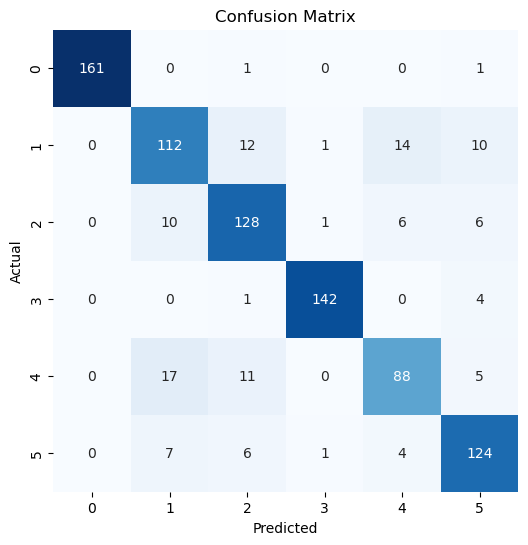

In [246]:
cm = confusion_matrix(y_test, predicted.cpu())

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [261]:
gc.collect()

39395

In [247]:
class PureLSTM(nn.Module):
    
    def __init__(self, n_features, n_hidden, n_sequence, n_layers, n_classes):
        super(PureLSTM, self).__init__()
        
        self.n_features = n_features
        self.n_hidden = n_hidden
        self.n_sequence = n_sequence
        self.n_layers = n_layers
        self.n_classes = n_classes
        
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=n_hidden, num_layers=n_layers, batch_first=True)
        
        self.linear_1 = nn.Linear(in_features=n_hidden, out_features=128)
        self.dropout_1 = nn.Dropout(p=0.2)
        
        self.linear_2 = nn.Linear(in_features=128, out_features=n_classes)        
        
    
    def forward(self, x):
        
        self.hidden = (
            torch.zeros(self.n_layers, x.shape[0], self.n_hidden).to(device),
            torch.zeros(self.n_layers, x.shape[0], self.n_hidden).to(device)
        )
    
        out, (hs, cs) = self.lstm(x.view(len(x), self.n_sequence, -1),self.hidden)
        out = out[:,-1,:]

        out = self.linear_1(out)
        out = self.dropout_1(out)
        out = self.linear_2(out)
        
        return out
    
def train_model(model, train_dataloader, n_epochs):
    global X_test_tensor, y_test_tensor
    
    running_loss = 0.0
    correct = 0
    total = 0
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer)
    
    for epoch in range(n_epochs):
        model.train()
        for i, (inputs, labels) in enumerate(train_dataloader):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Compute running loss and accuracy
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        scheduler.step(running_loss / total)
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_accuracy = correct / total * 100
        
        model.eval()
        with torch.no_grad():
            X_test_tensor = X_test_tensor.to(device)
            y_test_tensor = y_test_tensor.to(device)
            outputs = model(X_test_tensor)
            _, predicted = outputs.max(1)
            test_accuracy = predicted.eq(y_test_tensor).sum().item() / y_test_tensor.size(0) * 100

        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%")
        
    return model

In [ ]:
n_features = 4 #X_train.shape[1]
n_sequence=  int(X_train.shape[1] / n_features) #1
n_hidden = 16#32
n_layers = 2
epochs = 400
learning_rate = 0.01
# n_features = 4
# n_sequence= int(X_train_feat.shape[1] / n_features) #1
# n_hidden = 16#32
# n_layers = 1#2
# epochs = 400
# learning_rate = 0.01

model = PureLSTM(n_features, n_hidden, n_sequence, n_layers, output_size).to(device)

print("Train Data Shape ",X_train.shape, y_train.shape)
print("Test Data Shape ",X_test.shape, y_test.shape)
# print("Train Data Shape ",X_train_feat.shape, y_train_feat.shape)
# print("Test Data Shape ",X_test_feat.shape, y_test_feat.shape)

X_train_mod = X_train.reshape(X_train.shape[0], n_features, n_sequence)
X_train_mod = np.swapaxes(X_train_mod, 2, 1)

X_test_mod = X_test.reshape(X_test.shape[0], n_features, n_sequence)
X_test_mod = np.swapaxes(X_test_mod, 2, 1)
# X_train_mod = X_train_feat.reshape(X_train_feat.shape[0], n_features, n_sequence)
# X_train_mod = np.swapaxes(X_train_mod, 2, 1)

# X_test_mod = X_test_feat.reshape(X_test_feat.shape[0], n_features, n_sequence)
# X_test_mod = np.swapaxes(X_test_mod, 2, 1)
print("Train Data Shape ",X_train_mod.shape)
print("Test Data Shape ",X_test_mod.shape)

X_train_tensor = torch.tensor(X_train_mod, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_mod, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model = train_model(model, train_loader, n_epochs = epochs)

Train Data Shape  (3489, 800) (3489,)
Test Data Shape  (873, 800) (873,)
Train Data Shape  (3489, 200, 4)
Test Data Shape  (873, 200, 4)
Epoch 1/400, Loss: 1.7225, Accuracy: 23.70%, Test Accuracy: 24.86%
Epoch 2/400, Loss: 3.4014, Accuracy: 24.18%, Test Accuracy: 27.26%
Epoch 3/400, Loss: 5.0798, Accuracy: 24.83%, Test Accuracy: 28.06%
Epoch 4/400, Loss: 6.6798, Accuracy: 25.66%, Test Accuracy: 30.13%
Epoch 5/400, Loss: 8.3057, Accuracy: 26.36%, Test Accuracy: 29.78%
Epoch 6/400, Loss: 9.8813, Accuracy: 26.96%, Test Accuracy: 33.33%
Epoch 7/400, Loss: 11.4077, Accuracy: 27.83%, Test Accuracy: 32.65%
Epoch 8/400, Loss: 12.8879, Accuracy: 28.61%, Test Accuracy: 32.19%
Epoch 9/400, Loss: 14.3700, Accuracy: 29.01%, Test Accuracy: 37.57%
Epoch 10/400, Loss: 15.7702, Accuracy: 29.63%, Test Accuracy: 40.78%
Epoch 11/400, Loss: 17.1139, Accuracy: 30.42%, Test Accuracy: 44.44%
Epoch 12/400, Loss: 18.4436, Accuracy: 31.11%, Test Accuracy: 41.24%
Epoch 13/400, Loss: 19.7474, Accuracy: 31.79%, Tes

In [255]:
torch.save(model.state_dict(), 'custom_lstm_transformed_features.pth')

def evaluateModel(outputs, y):
    _, predicted = outputs.max(1)
    test_accuracy = predicted.eq(y).sum().item() / y.size(0) * 100
    return test_accuracy, predicted

model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    y_test_tensor = y_test_tensor.to(device)
    y_hat_test = model(X_test_tensor)
    acc, predicted = evaluateModel(y_hat_test, y_test_tensor)
    print(f"Test Accuracy: {acc:.2f}%")

Test Accuracy: 89.81%


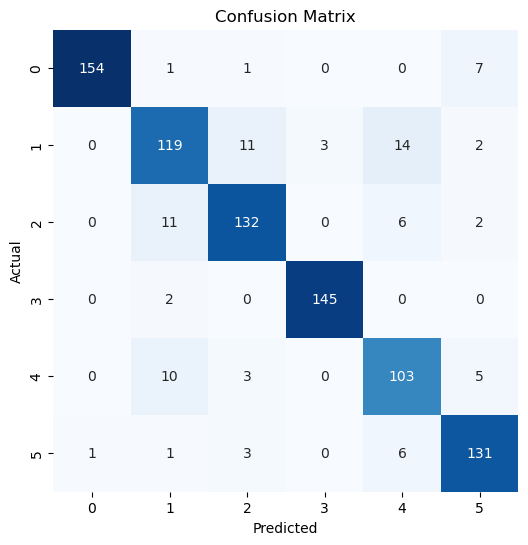

In [256]:
cm = confusion_matrix(y_test, predicted.cpu())

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Feature engineering